In [ ]:
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_percentage_error


# For 2D analysis
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.preprocessing import MinMaxScaler
# from utils import period2freq, freq2period

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import csv
import time
import glob

# Datasize in KB
data_size_kb = {'4mb': 4096, '16mb': 16384, '64mb': 65536,
            '256mb': 262144, '512mb': 524288, '1gb': 1048576,
            '5gb': 5242880, '50gb': 52428800, '100gb': 104857600,
            '300gb': 314572800,}

# Key Parameters
IOR_PARAMS = ['operation', 'randomOffset', 'transferSize', 
            'aggregateFilesizeMB', 'numTasks', 'totalTime', 
            'numNodes', 'tasksPerNode', 'parallelism', 'trMiB', "storageType"]

TARGET_PARAMS = [ "bestStorage" ]
op_dict = {0: "write", 1: "read"}


## transfer rate Prediction from IOR to Workflow
### Key parameters from IOR
Parameters for emulation:
- D: Total I/O size per task per operation (take log scale)
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: transfer rate calculated from TIO/T
### Special note for IOR
IOR calculates trMiB, but the trMiB is little slower than the (aggregate filesize)/totalTime, but not much difference, particularly in the `totalTime=openTimewrRdTime+closetime`

### Key parameters from workflow
Parameters for characteristics
- D: Total I/O size per task per operation (take log scale)
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, calculate from A=D/C [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: transfer rate calculated from TIO/T

### Perf Modeling Parameters
- a: Performance change when total data size reaches memory buffer cache of system.
- b: Performance change when  total data size reaches memory size of system. (Constant value)
- v: Performance variation due to shared storage resource. 
(The peak variation in the system. Measure with IOR.)
Deception BeeGFS: run at off hour to keep below 20% variation.
Options: (1) User/system admin to ensure the variation percentage; 
(2) Obtain variation with IOR emulation (possible over 20%)
- r: Range of expected performance: Make correct choice with given storage options.
- LPMR: Layered performance matching number for comparing application storage choice.
- w: Weight of a application LPMR. (Total data size, cost of moving data)



# TODO
- normalize BW differently! use same log scale for all (DONE)
- BeeGFS graph show variance:
    - identify whether the performance changes is due to BeeGFS parameters or due to traffic
    - parameter: distribution, tell us the load at particular time, background traffic under a percentage 5%, parameter it self can be a range.
    - Microbenchmark on background load, in principle that we know this exists and we assume we know a load factor, adjust the results. Whether it affect the storage choice for a type of workload.
    

In [1]:
def byte_size_to_human_size(byte_size):
    if byte_size < 1024:
        return f"{byte_size} B"
    elif byte_size < 1024**2:
        return f"{byte_size/1024} KiB"
    elif byte_size < 1024**3:
        return f"{byte_size/1024**2} MiB"
    elif byte_size < 1024**4:
        return f"{byte_size/1024**3} GiB"
    else:
        return f"{byte_size/1024**4} TiB"

def file_size_to_mb(file_size):
    # If file_size is type string, convert to float
    if type(file_size) == str:
        # Translate KiB, MiB, and GiB to bytes
        size_num = float(file_size.split(" ")[0])
        size_unit = file_size.split(" ")[1]
        if size_unit == "KiB":
            return float(size_num/1024)
        elif size_unit == "MiB":
            return float(size_num)
        elif size_unit == "GiB":
            return float(size_num * 1024)
        else:
            # If file_size is type int, convert to MB
            return int(size_num/1024**2)
    else:
        # If file_size is type int, convert to MB
        return int(file_size/1024**2)

def transform_store_code(storage_type):
    if storage_type == "localssd":
        store_code = 0
    elif storage_type == "beegfs":
        store_code = 1
    elif storage_type == "lustre":
        store_code = 2
    elif storage_type == "tmpfs":
        store_code = 3
    elif storage_type == "nfs":
        store_code = 4
    else:
        store_code = 5
    return store_code

def decode_store_code(store_code):
    mapping = {
        0: "localssd",
        1: "beegfs",
        2: "lustre",
        3: "tmpfs",
        4: "nfs"
    }
    return mapping.get(store_code, "unknown")

def get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS):


    # Create a dataframe for storing ior parameters
    ior_df = pd.DataFrame(columns=IOR_PARAMS)
    store_code = transform_store_code(storage_type)

    # Load Json files
    for jfile in ior_test_json_files:
        with open(jfile) as f:
            try:
                data = json.load(f)
            except:
                print("Error reading file: ", jfile)
                continue
            # print(jfile)
            
            # Write then Read
            ior_options = data['tests'][0]["Options"]
            IOR_PARAMS = data['tests'][0]["Parameters"]

            # Add write statistics first
            if file_size_to_mb(ior_options['aggregate filesize']) != 0:
                tmp_write_stat = {}
                # ior_write_config = data['tests'][0]
                ior_write_summary = data['summary'][0]
                # check if ior_write_summary is empty
                if ior_write_summary:
                    tmp_write_stat['randomOffset'] = IOR_PARAMS['randomOffset']
                    tmp_write_stat['aggregateFilesizeMB'] = file_size_to_mb(ior_options['aggregate filesize'])
                    tmp_write_stat['numTasks'] = ior_write_summary['numTasks']
                    tmp_write_stat['tasksPerNode'] = ior_write_summary['tasksPerNode']
                    tmp_write_stat['numNodes'] = IOR_PARAMS['nodes'] #tmp_write_stat['numTasks']/tmp_write_stat['tasksPerNode']
                    # if tmp_write_stat['numNodes'] > 1:print(f"Getting numNodes[{tmp_write_stat['numNodes']}]")
                    tmp_write_stat['parallelism'] = tmp_write_stat['numTasks']
                    tmp_write_stat['transferSize'] = ior_write_summary['transferSize']
                    if ior_write_summary['operation'] == "write":
                        tmp_write_stat['operation'] = 0
                    else:
                        tmp_write_stat['operation'] = -1
                    tmp_write_stat['totalTime'] = ior_write_summary['MeanTime'] # only 1 operation per test
                    tmp_write_stat['trMiB'] = ior_write_summary['bwMeanMIB'] # only 1 operation per test
                    tmp_write_stat['storageType'] = store_code
                    # Add tmp_write_stat to df
                    ior_df = ior_df._append(tmp_write_stat, ignore_index=True)
                else:
                    print("WARNING: Empty write summary")

                # Add read statistics
                tmp_read_stat = {}
                # ior_read_config = data['tests'][0]
                ior_read_summary = data['summary'][1]
                # check if ior_read_summary is empty
                if ior_read_summary:
                    tmp_read_stat['randomOffset'] = IOR_PARAMS['randomOffset']
                    tmp_read_stat['aggregateFilesizeMB'] = file_size_to_mb(ior_options['aggregate filesize'])
                    tmp_read_stat['numTasks'] = ior_read_summary['numTasks']
                    tmp_read_stat['tasksPerNode'] = ior_read_summary['tasksPerNode']
                    tmp_read_stat['numNodes'] = IOR_PARAMS['nodes'] #tmp_read_stat['numTasks']/tmp_read_stat['tasksPerNode']
                    tmp_read_stat['parallelism'] = tmp_read_stat['numTasks']
                    tmp_read_stat['transferSize'] = ior_read_summary['transferSize']
                    if ior_read_summary['operation'] == "read":
                        tmp_read_stat['operation'] = 1
                    else:
                        tmp_read_stat['operation'] = -1
                    tmp_read_stat['totalTime'] = ior_read_summary['MeanTime']
                    tmp_read_stat['trMiB'] = ior_read_summary['bwMeanMIB']
                    tmp_read_stat['storageType'] = store_code
                    # Add tmp_read_stat to df
                    ior_df = ior_df._append(tmp_read_stat, ignore_index=True)
                else:
                    print("WARNING: Empty read summary")

    # encode string to numbers
    le = preprocessing.LabelEncoder()
    for col in ior_df.columns:
        if pd.api.types.is_string_dtype(ior_df[col]):
            ior_df[col] = le.fit_transform(ior_df[col])

    # print(ior_df.head(5))

    return ior_df

def plot_heatmap(corrM,outfile):
    plt.figure(figsize=(14, 8))
    #labels = list(corrM.columns)
    plt.subplots_adjust(bottom=0.19)

    # # use only lower triangle
    # corrM = corrM.where(np.triu(np.ones(corrM.shape)).astype(np.bool))

    ## plot all correlation heatmap
    map = sns.heatmap(corrM, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='grey', cmap='BrBG') #annot=True,
    map.set_title('Correlation Matrix Heatmap', fontdict={'fontsize':12}, pad=12)
    #plt.show()
    out_file=f'{outfile}.png'
    plt.savefig(out_file)
    plt.clf()

def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop
    
def corrM_sorted_csv(corrM, outfile):
  n=5
  au_corr = corrM.corr().abs().unstack()
  labels_to_drop = get_redundant_pairs(corrM)
  au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
  sorted_corrM = au_corr[0:n]

  out_file= outfile
  sorted_corrM.to_csv(out_file)

def corr_matrix(df,outname=""):

    # calculte correlation matrix
    corrM = df.corr()

    corrM.to_csv(f'{outname}.csv')
    plot_heatmap(corrM,outname)
    #corrM_sorted_csv(corrM, f'sorted_{outname}.csv')

def _2d_trend(X, y, x_label="x-axis", y_label="trMiB", title="", show=False):
        # X = X.reshape(-1, 1)
        X = X.values.reshape(-1, 1)
        # poly = PolynomialFeatures(degree=2)
        poly = PolynomialFeatures(degree=1)
        poly_data = poly.fit_transform(X)
        model = LinearRegression()
        model.fit(poly_data,y)
        coef = model.coef_
        intercept = model.intercept_
        # Set figure size (80,50)
        plt.figure(figsize=(10,5))

        plt.scatter(X,y,color='red')
        plt.plot(X,model.predict(poly.fit_transform(X)),color='blue')
        # Show the fit parameters on graph with scientific notation
        plt.annotate(f"y = {coef[1]:.2e}x + {intercept:.2e}", xy=(0.05, 0.95), xycoords='axes fraction')

        # print(f"y = {coef[1]}x + {intercept}")
        plt.legend(['Original','Prediction'])
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        if show:
            plt.show()
        return coef[1], intercept

def _3d_trend(x,y,z, title=""):
    # ref: https://stackoverflow.com/questions/2298390/fitting-a-line-in-3d
    # Convert Pandas Series to NumPy arrays
    x = x.to_numpy()
    y = y.to_numpy()
    z = z.to_numpy()
    
    data = np.concatenate((x[:, np.newaxis], 
                        y[:, np.newaxis], 
                        z[:, np.newaxis]), 
                        axis=1)
    
    data = data.astype('float64')

    # Calculate the mean of the points, i.e. the 'center' of the cloud
    datamean = data.mean(axis=0)
    print(datamean)

    # Do an SVD on the mean-centered data.
    # full_matrices=False reduce memory
    uu, dd, vv = np.linalg.svd(data - datamean, full_matrices=False)

    # Get the sptread of data with mean 0 from all axis
    x_min = np.min(data[:,0])
    y_min = np.min(data[:,1])
    z_min = np.min(data[:,2])

    x_max = np.max(data[:,0])
    y_max = np.max(data[:,1])
    z_max = np.max(data[:,2])

    low_bound = min(x_min, y_min, z_min)
    high_bound = max(x_max, y_max, z_max)

    # Now vv[0] contains the first principal component, i.e. the direction
    # vector of the 'best fit' line in the least squares sense.
    # Adjust axist limits (Optional)
    linepts = vv[0] * np.mgrid[low_bound:high_bound:2j][:, np.newaxis]
    # shift by the mean to get the line in the right place
    linepts += datamean

    # Verify that everything looks right.

    # import mpl_toolkits.mplot3d as m3d
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter3D(*data.T)
    ax.plot3D(*linepts.T)
    # ax.scatter3D(data[:,0], data[:,1], data[:,2])
    ax.set_xlabel("transferSize")
    ax.set_ylabel("aggregateFilesizeMB")
    ax.set_zlabel("trMiB")
    ax.set_title(title)
    plt.show()



In [2]:



def _linear_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Fit the linear regression model
    reg = LinearRegression()
    reg.fit(pca_df[['PC1']], pca_df['PC2'])

    # Predict values using the fitted model
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_line = reg.predict(x_vals.reshape(-1, 1))

    # Visualizing the PCA result and the fitted line
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_line, color='red', label='Linear Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Linear fit parameters
    print(f'Linear fit parameters: intercept={reg.intercept_}, slope={reg.coef_[0]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')


def ior_json_to_df(ior_data_path):
    # Get the list of JSON files from the directory
    ior_test_json_files = glob.glob(ior_data_path + "/*.json")

    # Get storage type from data_path name
    # storage_type =  ior_data_path.split("/")[-1].split("_")[0] + "_" + ior_data_path.split("/")[-1].split("_")[1]
    storage_type =  ior_data_path.split("/")[-1].split("_")[0]
    # print("Storage Type: ", storage_type)
    ior_df = get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS)

    # corr_matrix(ior_df, storage_type)

    return ior_df

# Take a column name for y_data
def x_mean_std(group, y_column):
    return pd.Series({
        f'{y_column}_ave': group[y_column].mean(),
        f'{y_column}_ave_std': group[y_column].std(ddof=0)  # Use population standard deviation by setting ddof=0
    })


def my_data_transform(df, cols_to_norm=[], cols_to_log=[]):
    # Create an empty DataFrame to store the results
    results = []

    # Get unique transfer sizes and number of tasks
    xfersizes = sorted(df['transferSize'].unique())
    numTasks = sorted(df['numTasks'].unique())
    op_type = [0, 1]  # Define outside the loop to avoid redefinition
    print("Transfer Sizes: ", xfersizes)
    print("Number of Tasks: ", numTasks)

    for xfer in xfersizes:
        for t in numTasks:
            for op in op_type:
                # Filter the DataFrame for specific conditions
                subdf = df[(df['numTasks'] == t) &
                           (df['transferSize'] == xfer) &
                           (df['operation'] == op)].copy()
                
                if not subdf.empty:
                    # Calculate the mean and standard deviation of the trMiB column
                    ave_tr_df = subdf.groupby('aggregateFilesizeMB').apply(
                        lambda group: x_mean_std(group, 'trMiB')
                    ).reset_index()

                    # Calculate percentage of standard deviation
                    ave_tr_df['trMiB_ave_std_perc'] = (ave_tr_df['trMiB_ave_std'] /
                                                       ave_tr_df['trMiB_ave']) * 100

                    # Merge the aggregated results with the original DataFrame
                    merged_df = pd.merge(subdf, ave_tr_df, on='aggregateFilesizeMB', how='left')

                    # Append the merged DataFrame to the results list
                    results.append(merged_df)

    # Concatenate all the DataFrames in the results list
    new_df = pd.concat(results, ignore_index=True)

    # Log transformation
    if cols_to_log:
        log_new_cols = [f"{col}_log" for col in cols_to_log]
        print("Columns to log: ", cols_to_log)
        new_df[log_new_cols] = np.log(new_df[cols_to_log])

    # Min-Max normalization
    if cols_to_norm:
        norm_new_cols = [f"{col}_norm" for col in cols_to_norm]
        print("Columns to normalize: ", cols_to_norm)
        scaler = MinMaxScaler()
        new_df[norm_new_cols] = scaler.fit_transform(new_df[cols_to_norm])

    return new_df

def oscillatory_func(x, amplitude, frequency, phase, offset):
    return amplitude * np.sin(frequency * x + phase) + offset

def damped_sine_func(x, amplitude, frequency, phase, offset, decay):
    return amplitude * np.sin(frequency * x + phase) * np.exp(-decay * x) + offset

def cos_func(x, amplitude, frequency):
    return amplitude * np.cos(frequency * x)

def normalize_y(y_data):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    return scaler.fit_transform(y_data.values.reshape(-1, 1)).flatten()

# def _oscillatory_trend(x_data, y_data, x_label="x-axis", y_label="trMiB", title="", 
#                        show=False, x_datalabel=[], y_datalabel=[], save_path=""):
#     # Normalize y_data
#     y_data_normalized = y_data #normalize_y(y_data)
    
#     # Initial guess for the parameters
#     amplitude_guess = (np.max(y_data_normalized) - np.min(y_data_normalized)) / 2
#     frequency_guess = 10
#     if y_data_normalized[1] > y_data_normalized[0]:
#         phase_guess = 0
#     else:
#         phase_guess = np.pi
#     offset_guess = np.mean(y_data_normalized)
#     initial_guess = [amplitude_guess, frequency_guess, phase_guess, offset_guess]

#     try:
#         # Fit the oscillatory function to the normalized data
#         params, params_covariance = curve_fit(oscillatory_func, x_data, y_data_normalized, p0=initial_guess, maxfev=10000)
#         # params, params_covariance = curve_fit(cos_func, x_data, y_data_normalized, p0=(amplitude_guess, frequency_guess), maxfev=10000)
#     except RuntimeError as e:
#         print(f"Sine wave fitting failed: {e}")
#         # Attempt to fit a damped sine wave if the initial fit fails
#         decay_guess = 0.1
#         frequency_guess = 20
#         # phase_guess2 = 1
#         phase_guess = np.pi
#         updated_guess = [amplitude_guess, frequency_guess, phase_guess, offset_guess]
#         try:
#             params, params_covariance = curve_fit(oscillatory_func, x_data, y_data_normalized, p0=initial_guess, maxfev=10000)
#         except RuntimeError as e:
#             print(f"Sine wave re-fitting failed: {e}")
#             return

#     # Print the fitted parameters
#     print("Fitted parameters:", params)

#     # Generate y values based on the fitted parameters
#     if len(params) == 4:
#         y_fitted = oscillatory_func(x_data, *params)
#         equation = f"y = {params[0]:.2f} * sin({params[1]:.2e}x + {params[2]:.2e}) + {params[3]:.2e}"
#     else:
#         y_fitted = damped_sine_func(x_data, *params)
#         equation = f"y = {params[0]:.2f} * sin({params[1]:.2e}x + {params[2]:.2e}) * exp(-{params[4]:.2e}x) + {params[3]:.2e}"

#     # set figure size
#     plt.figure(figsize=(10,5))

#     # Plot the original data as a scatter plot
#     plt.scatter(x_data, y_data_normalized, label='Data')

#     # Plot the fitted oscillatory curve
#     plt.plot(x_data, y_fitted, color='red', label='Fitted Curve')

#     # Add data labels foreach point
#     x_label_list = []
#     y_label_list = []
#     if len(x_datalabel) == len(x_data):
#         for i, label in enumerate(x_datalabel):
#             x_label_list.append(label)
#     if len(y_datalabel) == len(y_data):
#         for i, label in enumerate(y_datalabel):
#             y_label_list.append(label)
#     for i in range(len(x_data)):
#         plt.text(x_data[i], y_data_normalized[i], f"{x_label_list[i]}, {y_label_list[i]}", fontsize=8, ha='left', va='bottom')
    
#     # Always plot x and y from 0 to 1
#     plt.xlim(0, 1)
#     # plt.ylim(0, 1)

#     # Add labels and legend
#     plt.xlabel(x_label)
#     plt.ylabel(y_label)
#     if title:
#         plt.title(title)
#     else:
#         plt.title('Scatter Plot with Curve Fit')
#     plt.legend()
    
#     # Write the equation of the fitted curve on the plot
#     plt.annotate(equation, xy=(0.05, 0.25), xycoords='axes fraction')
#     # Add phase_guess and frequency_guess to the plot
#     plt.annotate(f"Phase: {params[2]:.2e}, Frequency: {params[1]:.2e}", xy=(0.05, 0.20), xycoords='axes fraction')

#     if show:
#         # Show the plot
#         plt.show()
    
#     if save_path != "":
#         # save with plt title
#         plt.savefig(f'{save_path}/{title}.png')



In [ ]:
ior_ssd_data_paths = [
        # "./perf_profiles/ior_data/localssd_ior_buffered_1n",
    "./perf_profiles/ior_data/localssd_pior_buffered_1n",
    "./perf_profiles/ior_data/localssd_pior_buffered_2n",
    "./perf_profiles/ior_data/localssd_pior_buffered_4n",
    "./perf_profiles/ior_data/localssd_pior_buffered_8n",
    "./perf_profiles/ior_data/localssd_pior_buffered_16n",
    "./perf_profiles/ior_data/localssd_pior_buffered_32n",
]

ior_beegfs_data_paths = [
    # "./perf_profiles/ior_data/beegfs_ior_buffered_1n",
    "./perf_profiles/ior_data/beegfs_pior_buffered_1n",
    "./perf_profiles/ior_data/beegfs_pior_buffered_2n",
    "./perf_profiles/ior_data/beegfs_pior_buffered_4n",
    "./perf_profiles/ior_data/beegfs_pior_buffered_8n",
    "./perf_profiles/ior_data/beegfs_pior_buffered_16n",
    "./perf_profiles/ior_data/beegfs_pior_buffered_32n",
]

ior_nfs_data_paths = [
    "./perf_profiles/ior_data/nfs_pior_buffered_1n",
    "./perf_profiles/ior_data/nfs_pior_buffered_2n",
    "./perf_profiles/ior_data/nfs_pior_buffered_4n",
    "./perf_profiles/ior_data/nfs_pior_buffered_8n",
    "./perf_profiles/ior_data/nfs_pior_buffered_16n",
    "./perf_profiles/ior_data/nfs_pior_buffered_32n",
]

ior_tmpfs_data_paths = [
    "./perf_profiles/ior_data/tmpfs_pior_buffered_1n",
    "./perf_profiles/ior_data/tmpfs_pior_buffered_2n",
    "./perf_profiles/ior_data/tmpfs_pior_buffered_4n",
    "./perf_profiles/ior_data/tmpfs_pior_buffered_8n",
    "./perf_profiles/ior_data/tmpfs_pior_buffered_16n",
    "./perf_profiles/ior_data/tmpfs_pior_buffered_32n",
]

def data_paths_to_df(ior_data_paths):
    path_ior_df = pd.DataFrame(columns=IOR_PARAMS)

    for ior_data_path in ior_data_paths:
        ior_df = ior_json_to_df(ior_data_path)
        path_ior_df = path_ior_df._append(ior_df, ignore_index=True)

    cols_to_log = ['aggregateFilesizeMB', 'transferSize'] # , 'transferSize'
    cols_to_norm = ['aggregateFilesizeMB_log', 'trMiB'] # 'transferSize', 'trMiB'
    # normalize data
    scaled_ior_df = my_data_transform(path_ior_df, cols_to_norm=cols_to_norm, cols_to_log=cols_to_log)

    return scaled_ior_df

ssd_df = data_paths_to_df(ior_ssd_data_paths)
beegfs_df = data_paths_to_df(ior_beegfs_data_paths)

nfs_df = data_paths_to_df(ior_nfs_data_paths)
tmpfs_df = data_paths_to_df(ior_tmpfs_data_paths)




NameError: name 'pd' is not defined

In [ ]:
# print(nfs_df.head(5))
# print(tmpfs_df.head(5))
print(beegfs_df[beegfs_df['numNodes'] == 4].head(5))

    operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
18        0.0           0.0          64.0               1024.0       4.0   
19        0.0           0.0          64.0               1024.0       4.0   
20        0.0           0.0          64.0               1024.0       4.0   
27        1.0           0.0          64.0               1024.0       4.0   
28        1.0           0.0          64.0               1024.0       4.0   

    totalTime  numNodes  tasksPerNode  parallelism     trMiB  storageType  \
18     2.2070       4.0           1.0          4.0  463.9802          1.0   
19     2.1866       4.0           1.0          4.0  468.3036          1.0   
20     2.1938       4.0           1.0          4.0  466.7690          1.0   
27     2.0492       4.0           1.0          4.0  499.7018          1.0   
28     2.0342       4.0           1.0          4.0  503.3818          1.0   

     trMiB_ave  trMiB_ave_std  trMiB_ave_std_perc  aggregateFilesizeMB_log  \
18

In [ ]:
# Make graph better

# Remove all rows aggregateFilesizeMB larger and equals to 102400.0 from both dataframe
ssd_df = ssd_df[ssd_df['aggregateFilesizeMB'] < 102400.0]
beegfs_df = beegfs_df[beegfs_df['aggregateFilesizeMB'] < 102400.0]

nfs_df = nfs_df[nfs_df['aggregateFilesizeMB'] < 102400.0]
tmpfs_df = tmpfs_df[tmpfs_df['aggregateFilesizeMB'] < 102400.0]

# # Remove all rows transferSize larger and 16777216 from both dataframe
# ssd_df = ssd_df[ssd_df['transferSize'] < 16777216]
# beegfs_df = beegfs_df[beegfs_df['transferSize'] < 16777216]


In [ ]:
# show the list of unique parallelism tasksPerNode when NumNodes = 8
print(ssd_df[ssd_df['numNodes'] == 1]['tasksPerNode'].unique())
print(beegfs_df[beegfs_df['numNodes'] == 1]['tasksPerNode'].unique())

print(nfs_df[nfs_df['numNodes'] == 1]['tasksPerNode'].unique())
print(tmpfs_df[tmpfs_df['numNodes'] == 1]['tasksPerNode'].unique())

# # Filter the DataFrame to only include rows with numNodes == 1
# filtered_df = nfs_df[nfs_df['numNodes'] == 1]

# # Loop over unique tasksPerNode values
# for tasks_per_node in sorted(filtered_df['tasksPerNode'].unique()):
#     transfer_sizes = filtered_df[filtered_df['tasksPerNode'] == tasks_per_node]['transferSize'].unique()
#     print(f"tasksPerNode = {tasks_per_node} → transferSizes: {sorted(transfer_sizes)}")


[256.   2.   4.   8.  16.  32.  64. 128.]
[  2.   4.   8.  16.  32.  64. 128. 256.]
[  2.   4.   8.  16.  32.  64. 128.]
[  2.   4.   8.  16.  32.  64. 128. 256.]


In [ ]:
import os

def analyze_df(scaled_ior_df, numTasks=1):
    # Initialize the DataFrame for storing results
    averaged_tr_df = pd.DataFrame()
    
    # Get storage type from df
    storage_code = scaled_ior_df['storageType'].unique()[0]
    storage_type = decode_store_code(storage_code)

    # Get unique transfer sizes
    xfersizes = sorted(scaled_ior_df['transferSize'].unique().tolist())

    for xfer in xfersizes:
        op_type = [0, 1]
        op_dict = {0: "write", 1: "read"}

        for op in op_type:
            # Filter the DataFrame for specific conditions
            subdf = scaled_ior_df[(scaled_ior_df['numTasks'] == numTasks) &
                                  (scaled_ior_df['transferSize'] == xfer) &
                                  (scaled_ior_df['operation'] == op)]
            
            if not subdf.empty:
                # Perform the aggregation
                ave_tr_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(
                    lambda group: x_mean_std(group, 'trMiB_norm')).reset_index()
                # Plotting (as before)
                y_datalabel = [f"{y:.2e} ± {y_std:.2e}" for y, y_std in zip(
                    ave_tr_df['trMiB_norm_ave'], ave_tr_df['trMiB_norm_ave_std'])]
                
                save_path="./ior_seq_graph"
                # Make sure the directory exists
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                
                # _oscillatory_trend(
                #     ave_tr_df['aggregateFilesizeMB_log_norm'], 
                #     ave_tr_df['trMiB_norm_ave'], 
                #     x_label="aggregateFilesizeMB_log_norm", 
                #     y_label="trMiB_norm",
                #     title=f"[{op_dict[op]}] aggregateFilesizeMB vs trMiB with transferSize[{byte_size_to_human_size(xfer)}] on [{storage_type}]", 
                #     show=True, x_datalabel=sorted(subdf['aggregateFilesizeMB'].unique().tolist()), y_datalabel=y_datalabel,
                #     save_path=save_path
                # )
                
                

    # return averaged_tr_df

# analyze_df(ssd_df, numTasks=1)
# analyze_df(beegfs_df, numTasks=1)



# master_ior_df.to_csv("master_ior_df.csv")

In [ ]:
def _oscillatory_trend_multi_line(x_data_dict, y_data_dict, x_label, y_label, title, labels, show=True, save_path=None):
    """
    Plot multiple oscillatory trend lines on the same graph with labels.
    """
    if len(x_data_dict) == 0 or len(y_data_dict) == 0:
        print(f"Insufficient data points for plotting.")
        return  # Exit the function if data is insufficient

    try:
        plt.figure(figsize=(10, 10))  # Increased figure size for better resolution

        for label, x_data in x_data_dict.items():
            y_data = y_data_dict[label]
            plt.plot(x_data, y_data, 'o-', label=f"{labels[label]}")

        # Set font size for title, labels, legend, and axis ticks
        plt.xlabel(x_label, fontsize=30, labelpad=10)
        plt.ylabel(y_label, fontsize=30, labelpad=10)
        plt.title(title, fontsize=14)
        plt.xticks(fontsize=24)
        plt.yticks(fontsize=24)
        plt.legend(fontsize=30)
        plt.grid()

        if save_path:
            plt.savefig(f"{save_path}/{title.replace(' ', '_')}.png", dpi=300)  # High-resolution output
        if show:
            plt.show()
        plt.close()
    except Exception as e:
        print(f"Error plotting oscillatory trend: {e}")


def analyze_df_by_aggregateFilesizeMB(scaled_ior_df, numNodes=1):
    """
    Analyze the DataFrame by processing and plotting the transfer rate (trMiB) vs tasksPerNode
    for fixed values of transferSize and operation types, and multiple lines for unique aggregateFilesizeMB.
    """
    storage_code = scaled_ior_df['storageType'].unique()[0]
    storage_type = decode_store_code(storage_code)
    print(f"Storage Code[{storage_code}] Storage Type[{storage_type}]")
    print(f"scaled_ior_df size: {scaled_ior_df.shape}")

    # # Get unique combinations of transferSize and operation
    # unique_combinations = scaled_ior_df[['transferSize', 'operation']].drop_duplicates()

    for _, row in scaled_ior_df.iterrows():
        transfer_size = row['transferSize']
        operation = row['operation']
        op_dict = {0: "write", 1: "read"}

        # Filter by transferSize and operation
        subdf = scaled_ior_df[
            (scaled_ior_df['transferSize'] == transfer_size) &
            (scaled_ior_df['operation'] == operation) & 
            (scaled_ior_df['numNodes'] == numNodes)
        ]
        print(f"subdf size: {subdf.shape}")

        if not subdf.empty:
            # Group by AggregateFilesizeMB
            grouped = subdf.groupby('aggregateFilesizeMB')

            x_data_dict = {}
            y_data_dict = {}
            labels = {}

            for aggregate_size, group in grouped:
                ave_tr_df = group.groupby('tasksPerNode').apply(
                    lambda g: x_mean_std(g, 'trMiB')
                ).reset_index()

                if ave_tr_df.empty or len(ave_tr_df) < 2:
                    print(f"Skipping plot due to insufficient data points for TransferSize {transfer_size}, AggregateFilesizeMB {aggregate_size}, Operation {op_dict[operation]}")
                    continue

                x_data_dict[aggregate_size] = ave_tr_df['tasksPerNode']
                y_data_dict[aggregate_size] = ave_tr_df['trMiB_ave']
                labels[aggregate_size] = f"Total I/O: {int(aggregate_size/1024)} GB"

            if x_data_dict and y_data_dict:
                save_path = "./ior_seq_graph_tasksPerNode"
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                
                # Debug print on the list of unique tasksPerNode
                print(f"Unique tasksPerNode: {subdf['tasksPerNode'].unique()}")
                print(f"Unique tasksPerNode: {subdf['tasksPerNode'].unique()}")

                # Plot all lines on the same graph
                _oscillatory_trend_multi_line(
                    x_data_dict,
                    y_data_dict,
                    x_label="tasksPerNode",
                    y_label="Transfer Rate (MiB/s)",
                    title=f"[{op_dict[operation]}] TasksPerNode vs Transfer Rate | TransferSize: {byte_size_to_human_size(transfer_size)} | Storage: {storage_type}",
                    labels=labels,
                    show=True,
                    save_path=save_path
                )

# # Analyze SSD and BeeGFS DataFrames
# analyze_df_by_aggregateFilesizeMB(ssd_df, numNodes=2)
# analyze_df_by_aggregateFilesizeMB(beegfs_df, numNodes=4)
# analyze_df_by_aggregateFilesizeMB(nfs_df, numNodes=2)
# analyze_df_by_aggregateFilesizeMB(tmpfs_df, numNodes=2)




In [ ]:
def analyze_df_by_transfer_size(scaled_ior_df, numNodes=1):
    """
    Analyze the DataFrame by processing and plotting the transfer rate (trMiB) vs tasksPerNode
    for fixed values of aggregateFilesizeMB and operation types, and multiple lines for unique transferSize.
    """
    storage_code = scaled_ior_df['storageType'].unique()[0]
    storage_type = decode_store_code(storage_code)

    # Get unique combinations of aggregateFilesizeMB and operation
    unique_combinations = scaled_ior_df[['aggregateFilesizeMB', 'operation']].drop_duplicates()

    for _, row in unique_combinations.iterrows():
        aggregate_size = row['aggregateFilesizeMB']
        operation = row['operation']
        op_dict = {0: "write", 1: "read"}

        # Filter by aggregateFilesizeMB and operation
        subdf = scaled_ior_df[
            (scaled_ior_df['aggregateFilesizeMB'] == aggregate_size) &
            (scaled_ior_df['operation'] == operation) &
            (scaled_ior_df['numNodes'] == numNodes)
        ]

        if not subdf.empty:
            # Group by transferSize
            grouped = subdf.groupby('transferSize')

            x_data_dict = {}
            y_data_dict = {}
            labels = {}

            for transfer_size, group in grouped:
                ave_tr_df = group.groupby('tasksPerNode').apply(
                    lambda g: x_mean_std(g, 'trMiB')
                ).reset_index()

                if ave_tr_df.empty or len(ave_tr_df) < 2:
                    print(f"Skipping plot due to insufficient data points for AggregateFilesizeMB {aggregate_size}, TransferSize {transfer_size}, Operation {op_dict[operation]}")
                    continue

                x_data_dict[transfer_size] = ave_tr_df['tasksPerNode']
                y_data_dict[transfer_size] = ave_tr_df['trMiB_ave']
                labels[transfer_size] = f"TS: {byte_size_to_human_size(transfer_size)}"

            if x_data_dict and y_data_dict:
                save_path = "./ior_seq_graph_tasksPerNode_byTransferSize"
                if not os.path.exists(save_path):
                    os.makedirs(save_path)

                # Plot all lines on the same graph
                _oscillatory_trend_multi_line(
                    x_data_dict,
                    y_data_dict,
                    x_label="tasksPerNode",
                    y_label="Transfer Rate (MiB/s)",
                    title=f"[{op_dict[operation]}] TasksPerNode vs Transfer Rate | AggregateFilesizeMB: {aggregate_size} | Storage: {storage_type}",
                    labels=labels,
                    show=True,
                    save_path=save_path
                )

# Analyze SSD and BeeGFS DataFrames
# analyze_df_by_transfer_size(ssd_df, numNodes=2)
# analyze_df_by_transfer_size(beegfs_df, numNodes=4)

In [ ]:
# # Select df with std > 27
# ssd_sel_df = ssd_df[ssd_df['trMiB_ave_std_perc'] > 27]
# beegfs_sel_df = beegfs_df[beegfs_df['trMiB_ave_std_perc'] > 27]
# print(f"Original SSD DF [{ssd_df.shape}] to [{ssd_sel_df.shape}]")
# print(ssd_sel_df.head(2))
# print(f"Original BeeGFS DF [{beegfs_df.shape}] to [{beegfs_sel_df.shape}]")
# print(beegfs_sel_df.head(2))


# Show the 95th percentile of the trMiB_ave_std_perc column
print("95th percentile of trMiB_ave_std_perc column:")
print(f"SSD: {ssd_df['trMiB_ave_std_perc'].quantile(0.95)}")
print(f"BeeGFS: {beegfs_df['trMiB_ave_std_perc'].quantile(0.95)}")

# Show the 85th percentile of the trMiB_ave_std_perc column
print("85th percentile of trMiB_ave_std_perc column:")
print(f"SSD: {ssd_df['trMiB_ave_std_perc'].quantile(0.85)}")
print(f"BeeGFS: {beegfs_df['trMiB_ave_std_perc'].quantile(0.85)}")

# Select sequential read/write operations
ssd_seq_df = ssd_df[ssd_df['numTasks'] == 1]
beegfs_seq_df = beegfs_df[beegfs_df['numTasks'] == 1]
print(f"Sequential SSD DF: {ssd_seq_df.shape}")
print(f"Sequential BeeGFS DF: {beegfs_seq_df.shape}")
# Show the 95th percentile of the trMiB_ave_std_perc column
print("95th percentile of trMiB_ave_std_perc column for sequential operations:")
print(f"SSD: {ssd_seq_df['trMiB_ave_std_perc'].quantile(0.95)}")
print(f"BeeGFS: {beegfs_seq_df['trMiB_ave_std_perc'].quantile(0.95)}")

# Show the 85th percentile of the trMiB_ave_std_perc column
print("85th percentile of trMiB_ave_std_perc column for sequential operations:")
print(f"SSD: {ssd_seq_df['trMiB_ave_std_perc'].quantile(0.85)}")
print(f"BeeGFS: {beegfs_seq_df['trMiB_ave_std_perc'].quantile(0.85)}")




95th percentile of trMiB_ave_std_perc column:
SSD: 88.41329993792453
BeeGFS: 88.01436488591023
85th percentile of trMiB_ave_std_perc column:
SSD: 77.33447005276945
BeeGFS: 66.89292819276892
Sequential SSD DF: (0, 18)
Sequential BeeGFS DF: (0, 18)
95th percentile of trMiB_ave_std_perc column for sequential operations:
SSD: nan
BeeGFS: nan
85th percentile of trMiB_ave_std_perc column for sequential operations:
SSD: nan
BeeGFS: nan


In [ ]:
# Select sequential read/write that has trMiB_ave_std_perc > perc
perc = 20
ssd_seq_sel_df = ssd_seq_df[ssd_seq_df['trMiB_ave_std_perc'] > perc]
beegfs_seq_sel_df = beegfs_seq_df[beegfs_seq_df['trMiB_ave_std_perc'] > perc]
print(f"Sequential SSD DF with trMiB_ave_std_perc > {perc}: {ssd_seq_sel_df.shape}")
print(ssd_seq_sel_df)
print(f"Sequential BeeGFS DF with trMiB_ave_std_perc > {perc}: {beegfs_seq_sel_df.shape}")
print(beegfs_seq_sel_df)


Sequential SSD DF with trMiB_ave_std_perc > 20: (0, 18)
Empty DataFrame
Columns: [operation, randomOffset, transferSize, aggregateFilesizeMB, numTasks, totalTime, numNodes, tasksPerNode, parallelism, trMiB, storageType, trMiB_ave, trMiB_ave_std, trMiB_ave_std_perc, aggregateFilesizeMB_log, transferSize_log, aggregateFilesizeMB_log_norm, trMiB_norm]
Index: []
Sequential BeeGFS DF with trMiB_ave_std_perc > 20: (0, 18)
Empty DataFrame
Columns: [operation, randomOffset, transferSize, aggregateFilesizeMB, numTasks, totalTime, numNodes, tasksPerNode, parallelism, trMiB, storageType, trMiB_ave, trMiB_ave_std, trMiB_ave_std_perc, aggregateFilesizeMB_log, transferSize_log, aggregateFilesizeMB_log_norm, trMiB_norm]
Index: []


In [ ]:
beegfs_df.columns, beegfs_df.shape, ssd_df.columns, ssd_df.shape

# Merge the dataframes on columns other than 'storageType' and 'trMiB'

(Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
        'numTasks', 'totalTime', 'numNodes', 'tasksPerNode', 'parallelism',
        'trMiB', 'storageType', 'trMiB_ave', 'trMiB_ave_std',
        'trMiB_ave_std_perc', 'aggregateFilesizeMB_log', 'transferSize_log',
        'aggregateFilesizeMB_log_norm', 'trMiB_norm'],
       dtype='object'),
 (4748, 18),
 Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
        'numTasks', 'totalTime', 'numNodes', 'tasksPerNode', 'parallelism',
        'trMiB', 'storageType', 'trMiB_ave', 'trMiB_ave_std',
        'trMiB_ave_std_perc', 'aggregateFilesizeMB_log', 'transferSize_log',
        'aggregateFilesizeMB_log_norm', 'trMiB_norm'],
       dtype='object'),
 (4972, 18))

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

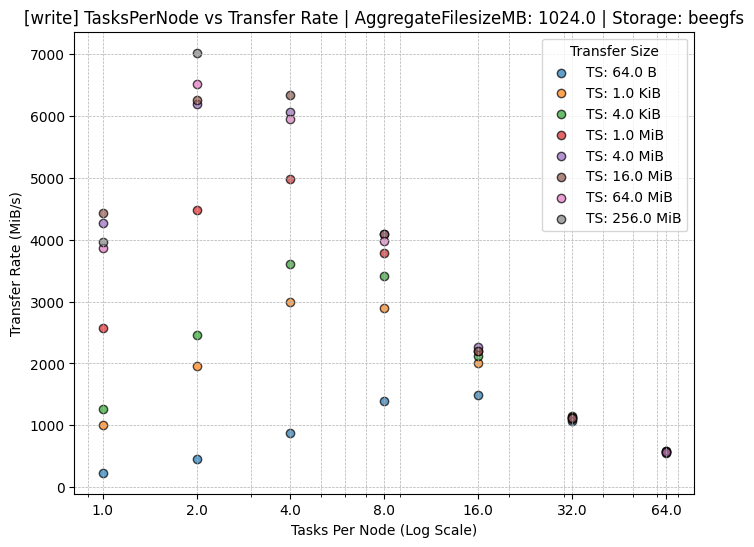

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

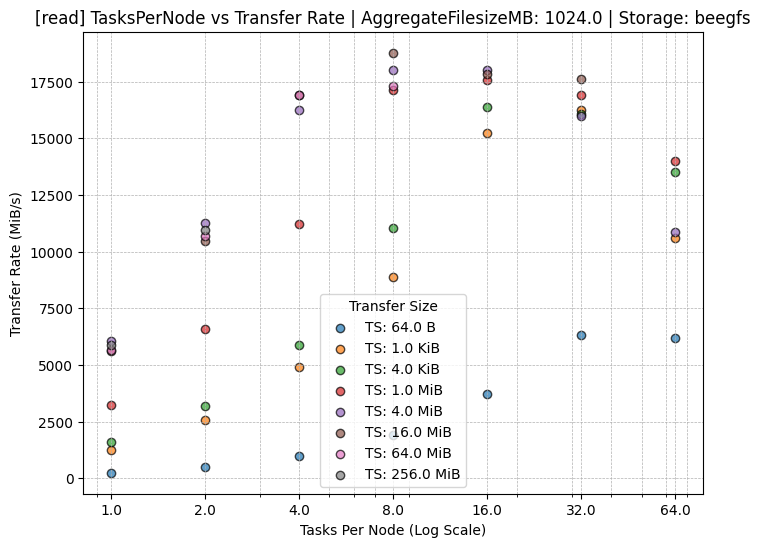

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 51200.0, TransferSize 1073741824.0, Operation write


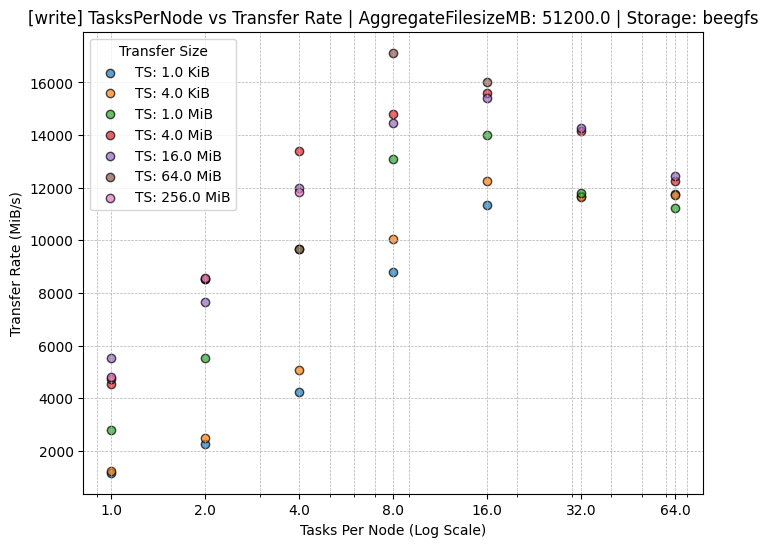

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

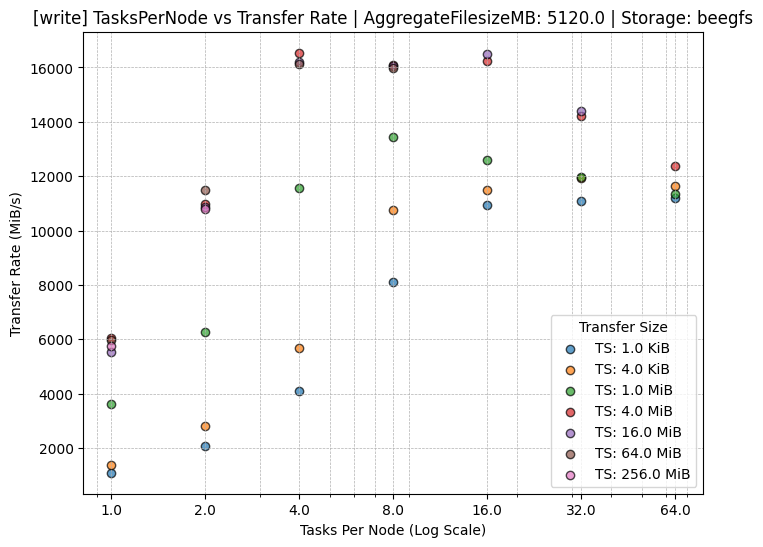

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 51200.0, TransferSize 1073741824.0, Operation read


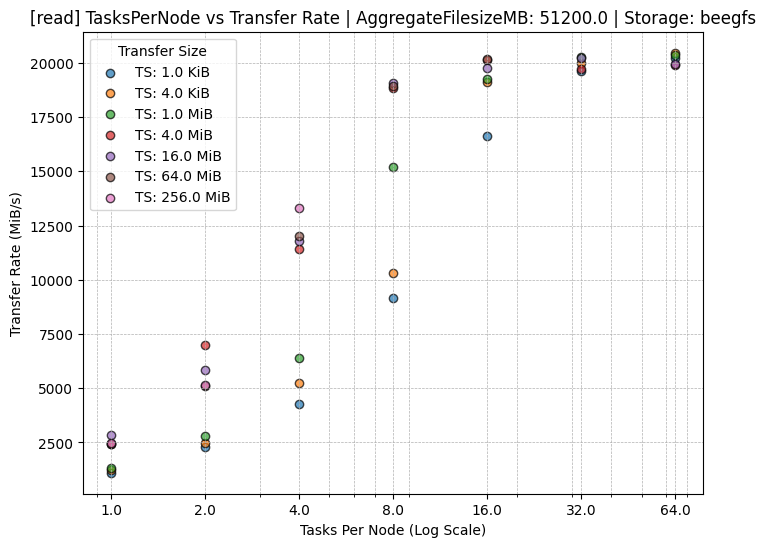

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

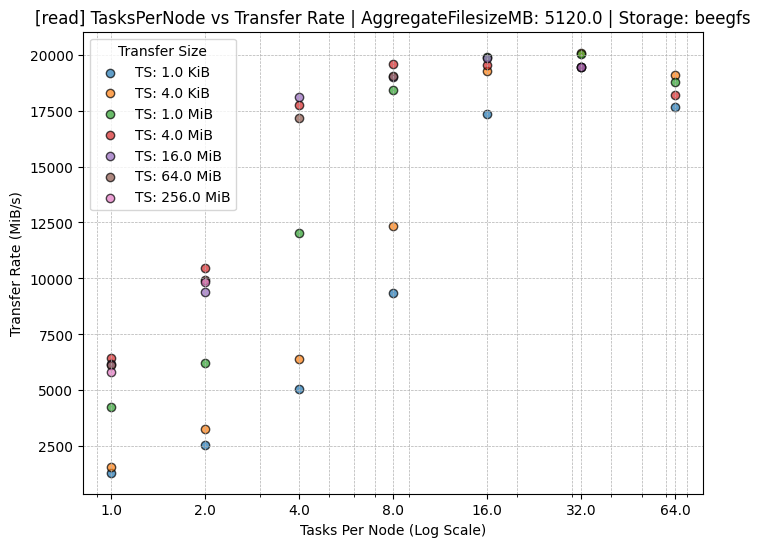

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 4096.0, TransferSize 16777216.0, Operation write


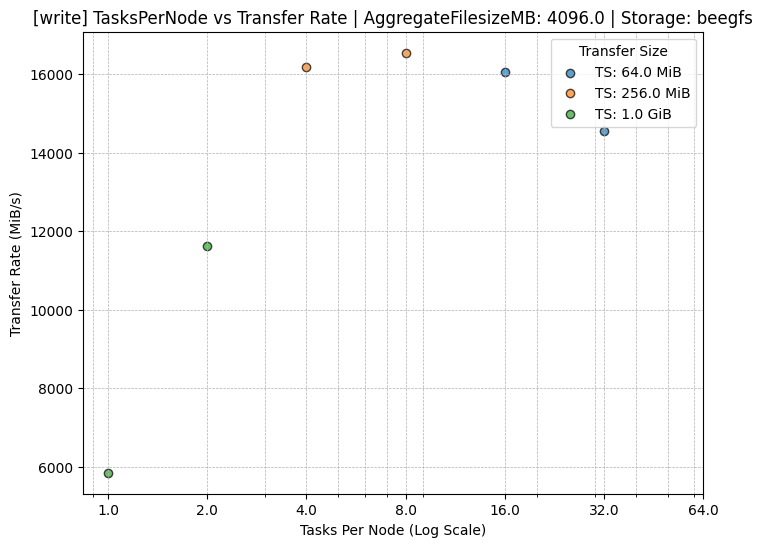

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 4096.0, TransferSize 16777216.0, Operation read


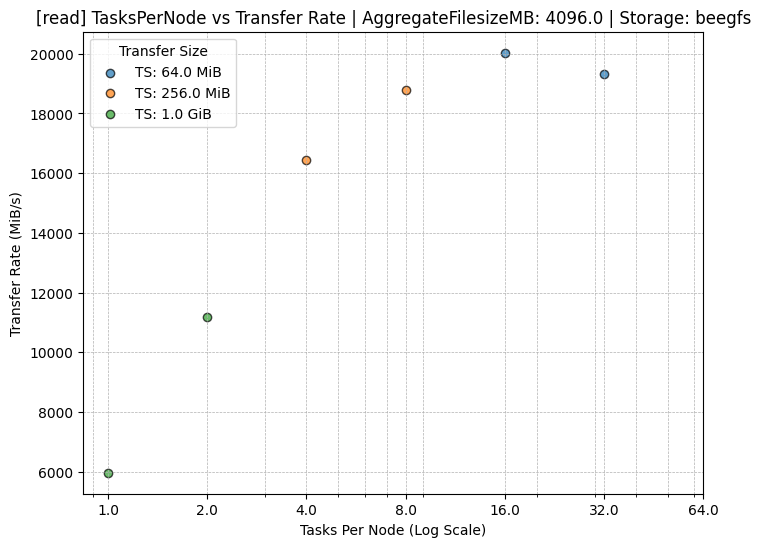

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

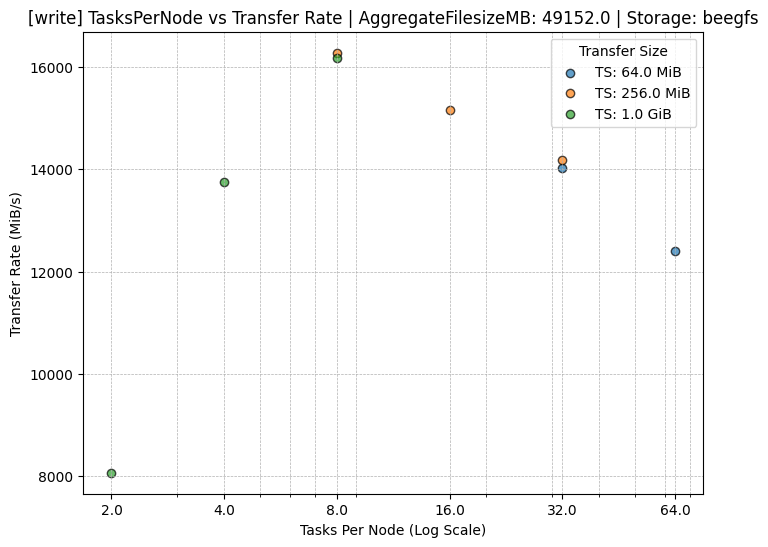

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

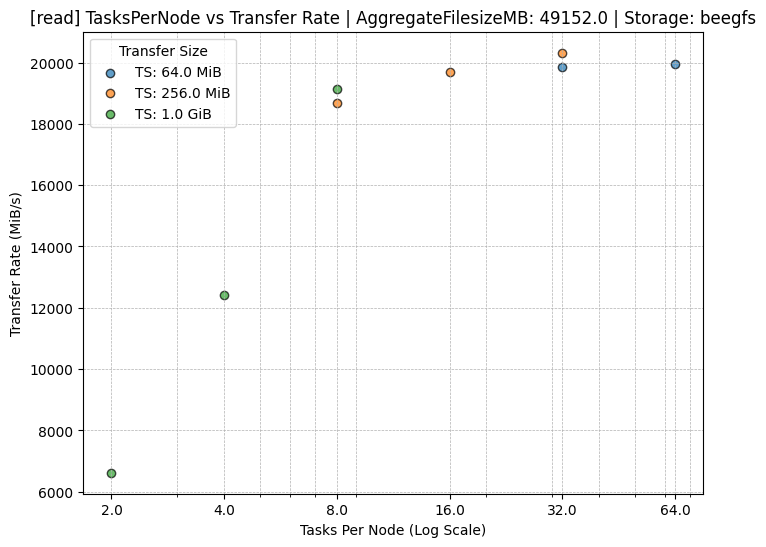

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with a

Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 268435456.0, Operation write
Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 1073741824.0, Operation write


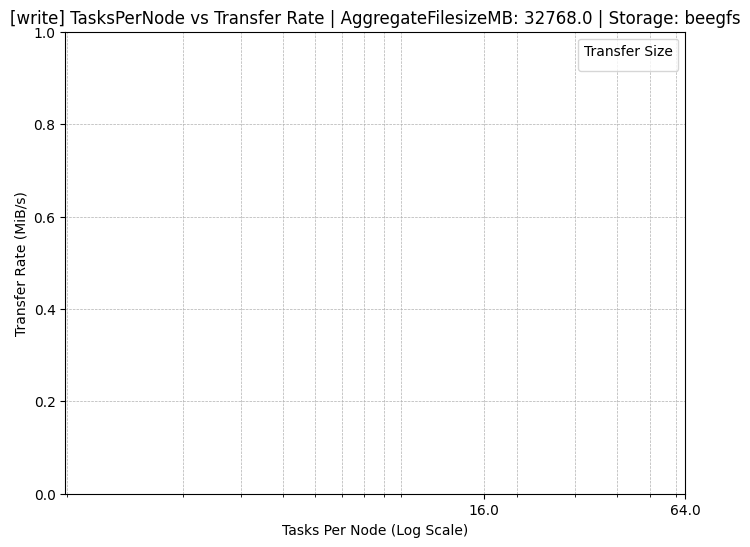

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with a

Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 268435456.0, Operation read
Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 1073741824.0, Operation read


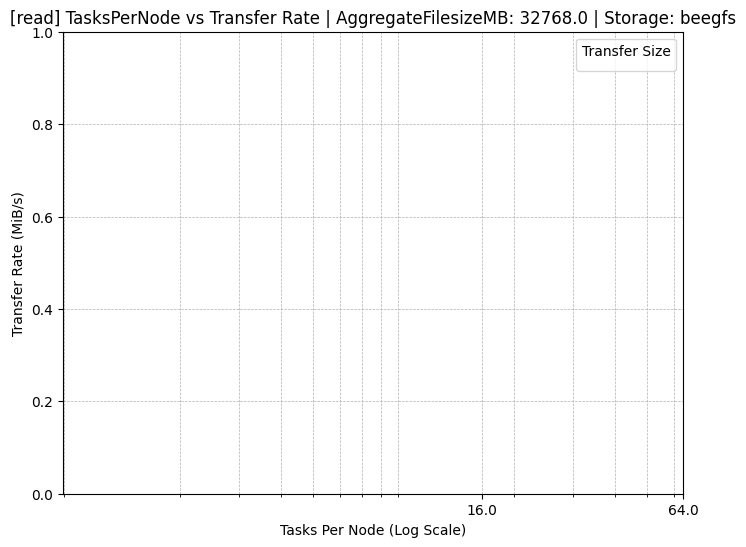

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

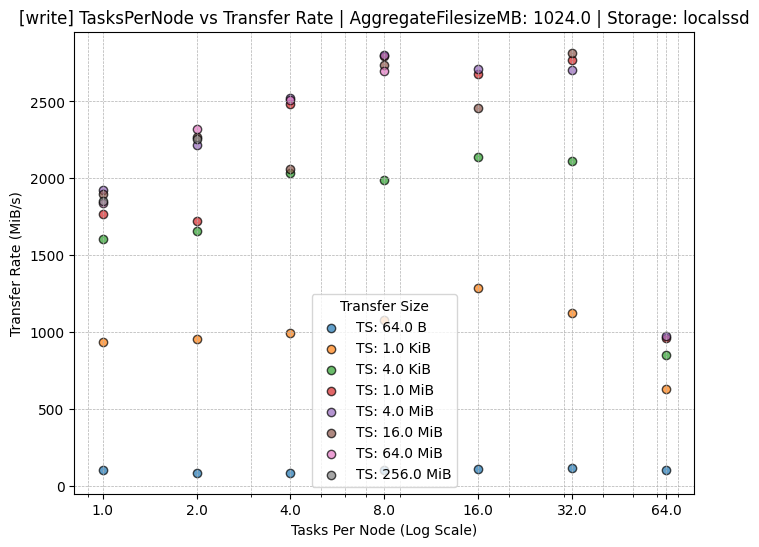

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

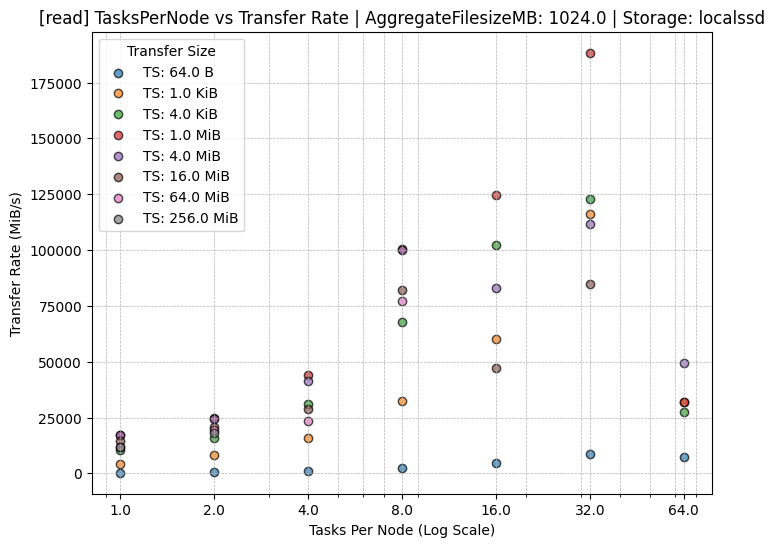

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 51200.0, TransferSize 1073741824.0, Operation write


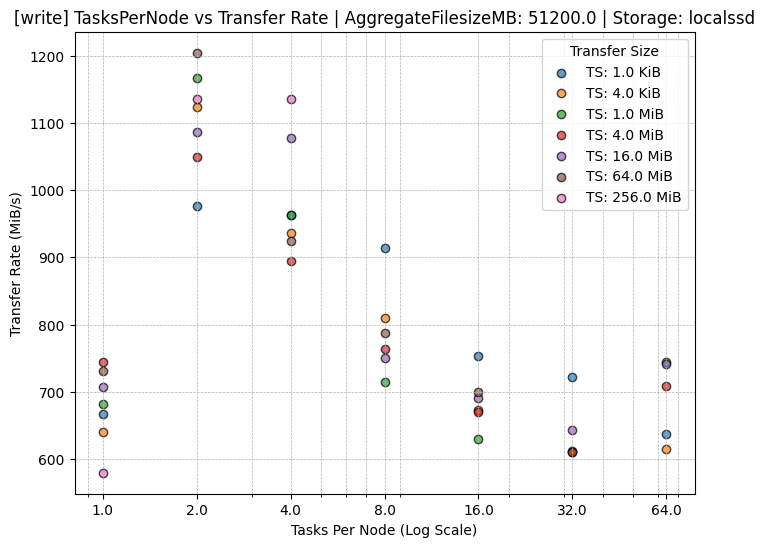

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

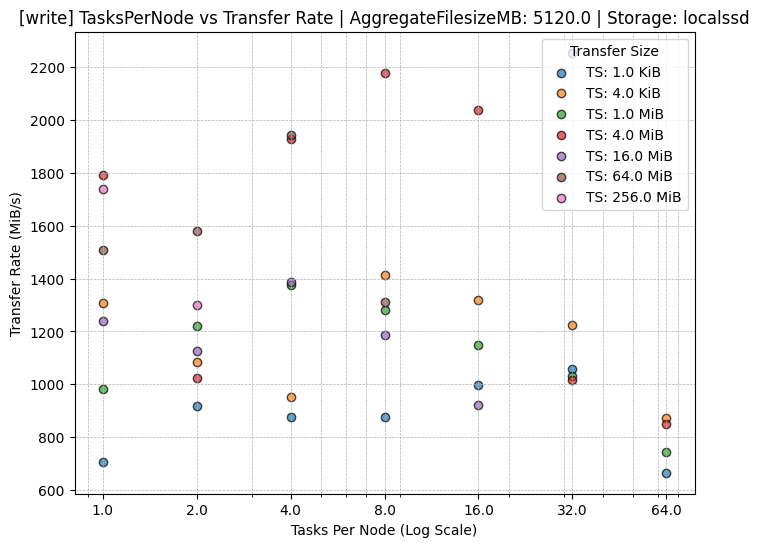

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 51200.0, TransferSize 1073741824.0, Operation read


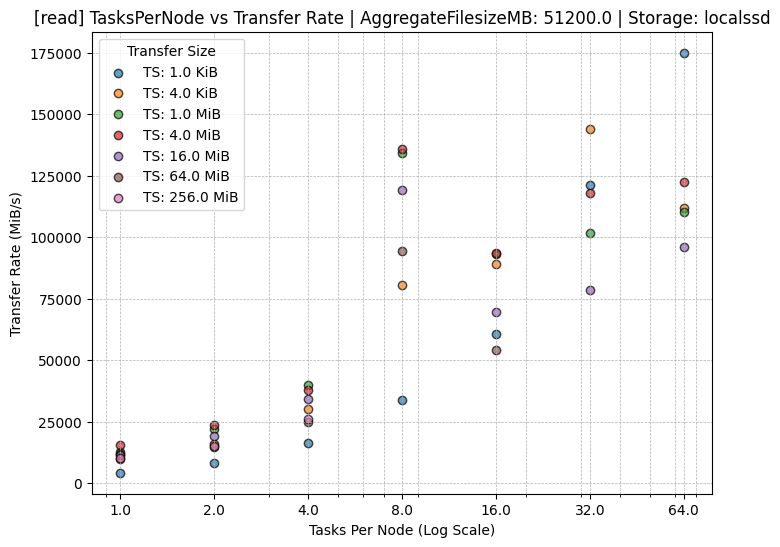

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

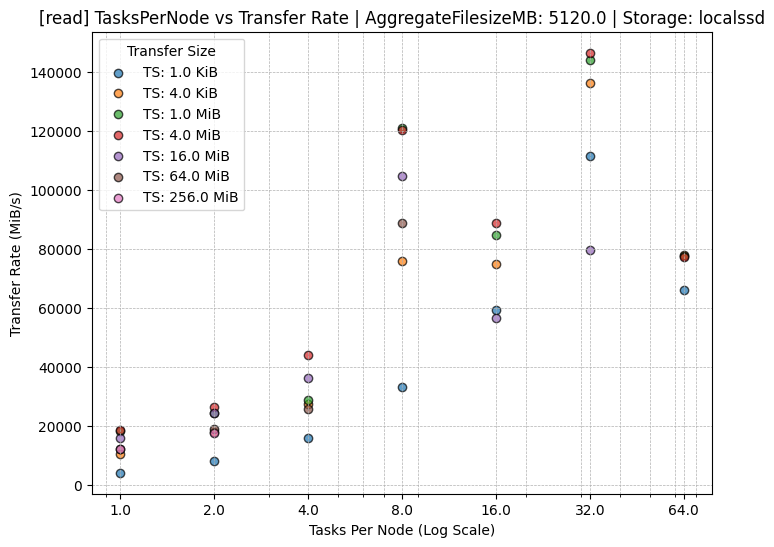

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 4096.0, TransferSize 16777216.0, Operation write


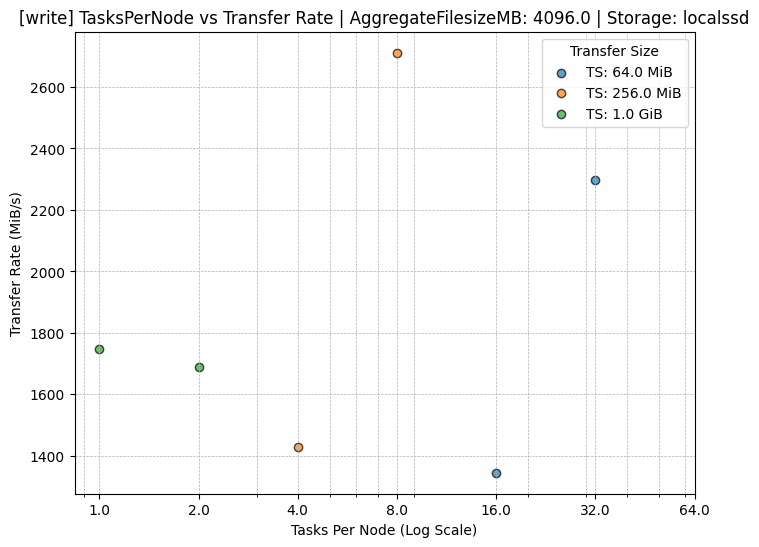

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 4096.0, TransferSize 16777216.0, Operation read


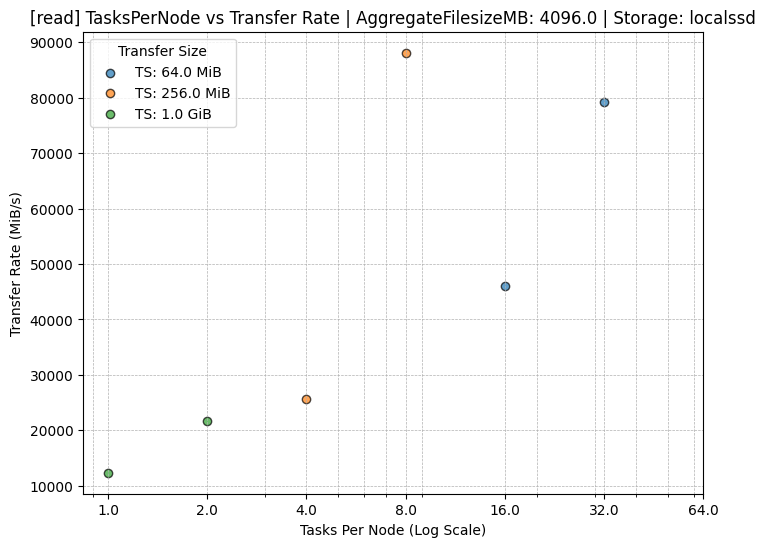

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

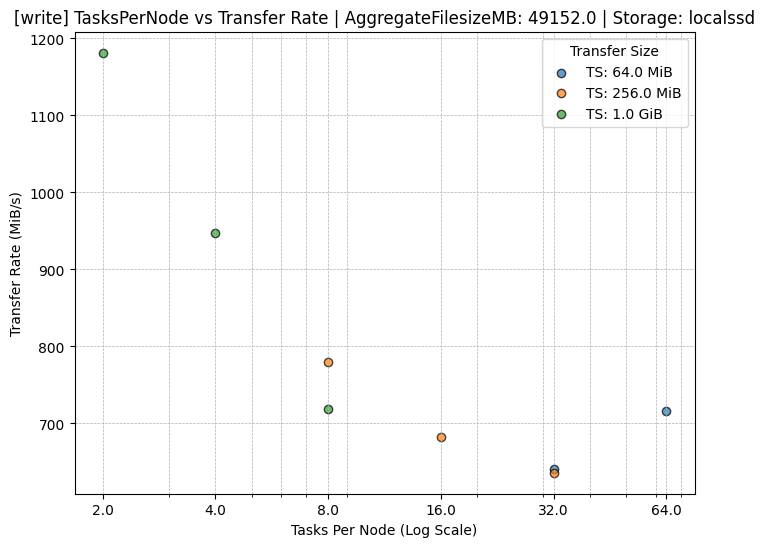

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

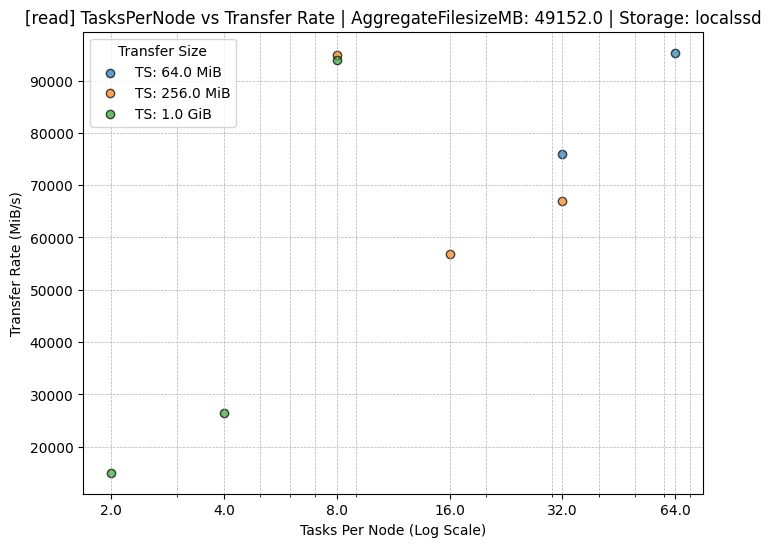

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with a

Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 268435456.0, Operation write
Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 1073741824.0, Operation write


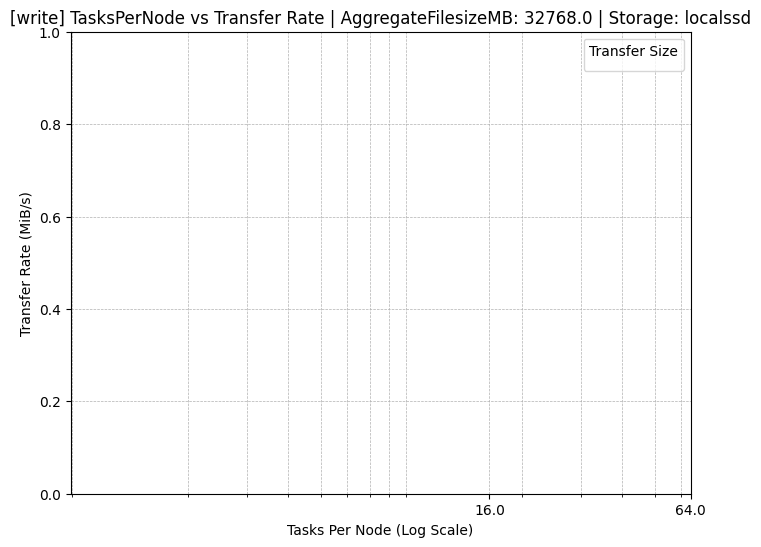

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with a

Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 268435456.0, Operation read
Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 1073741824.0, Operation read


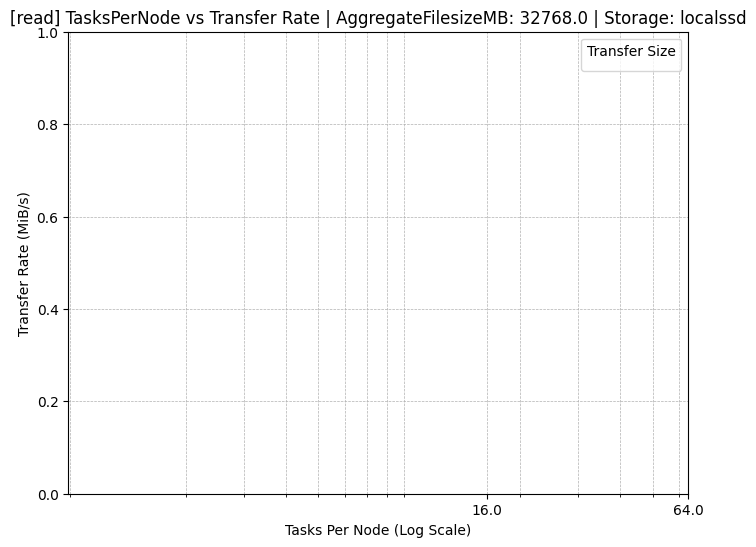

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

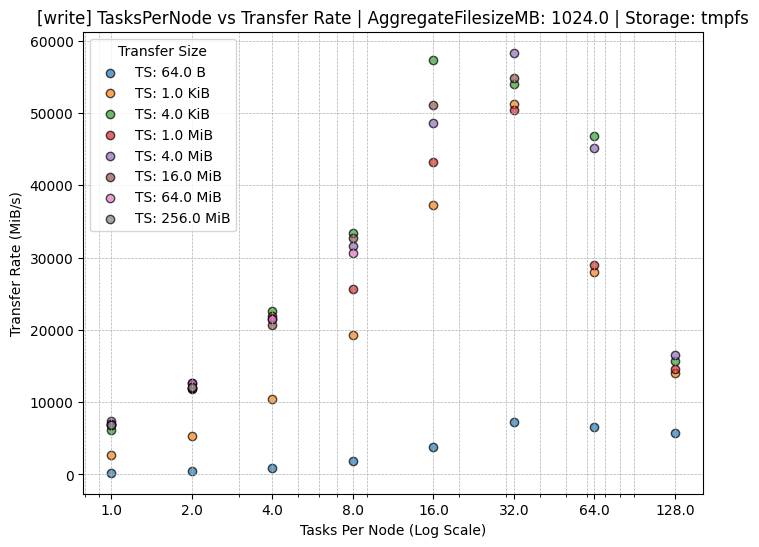

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

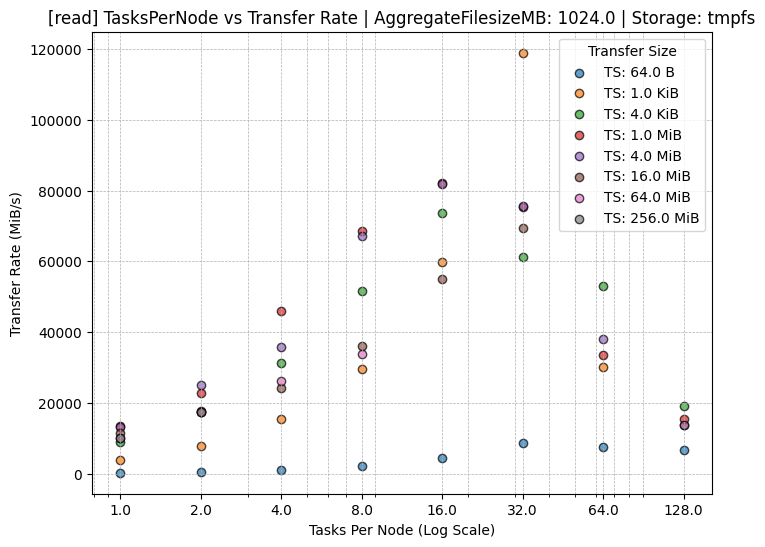

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 51200.0, TransferSize 1073741824.0, Operation write


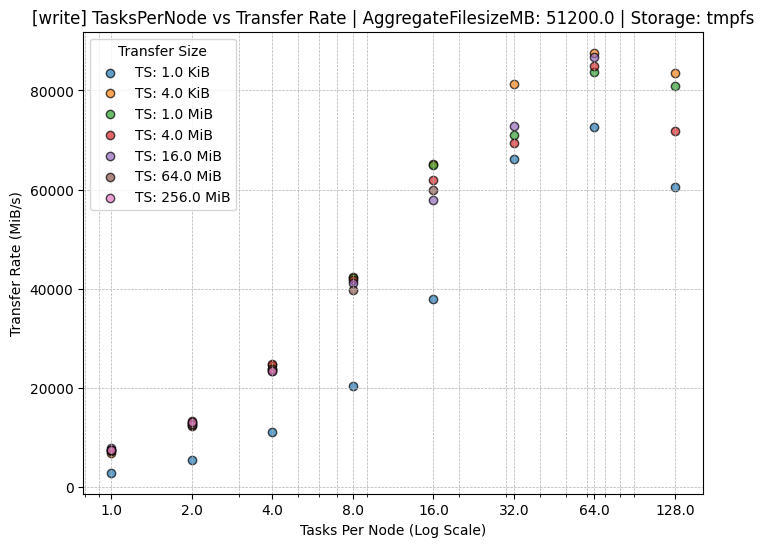

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

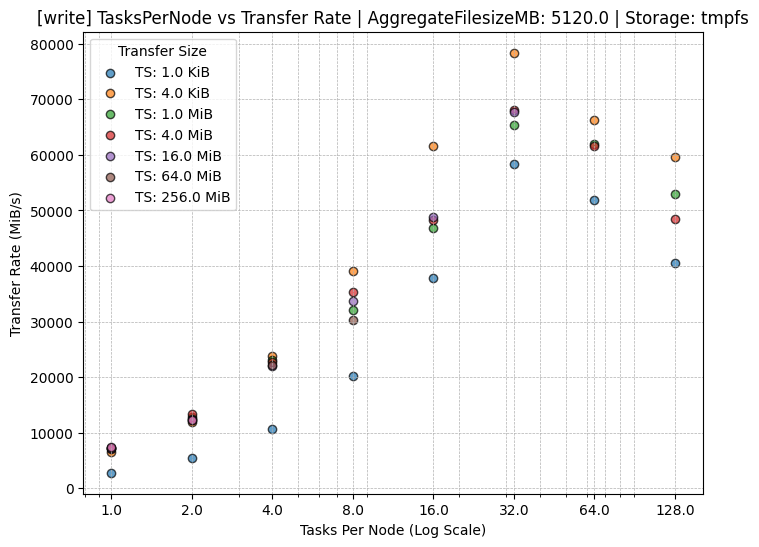

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 51200.0, TransferSize 1073741824.0, Operation read


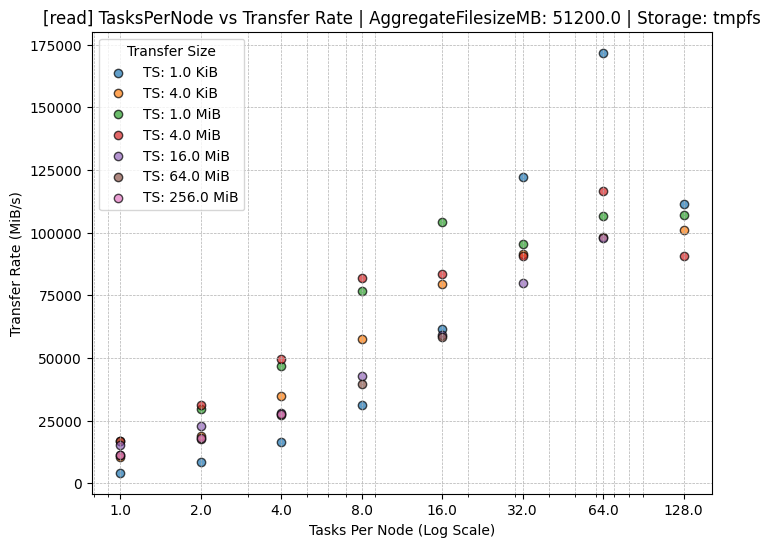

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

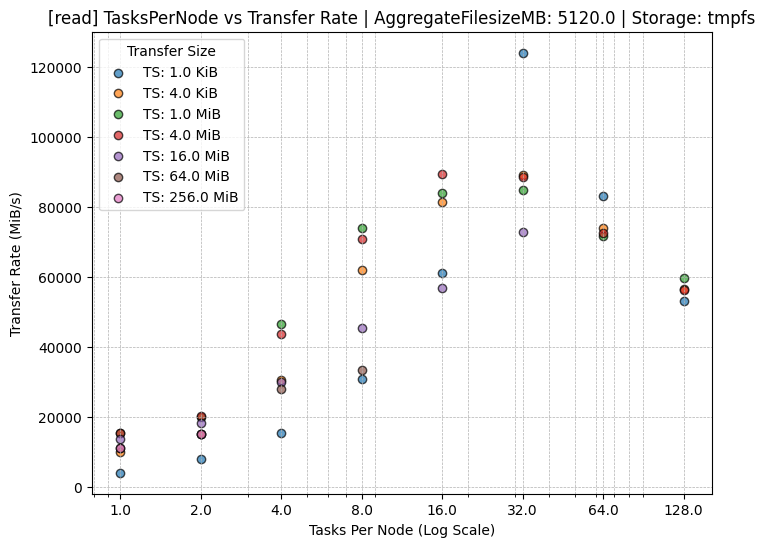

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

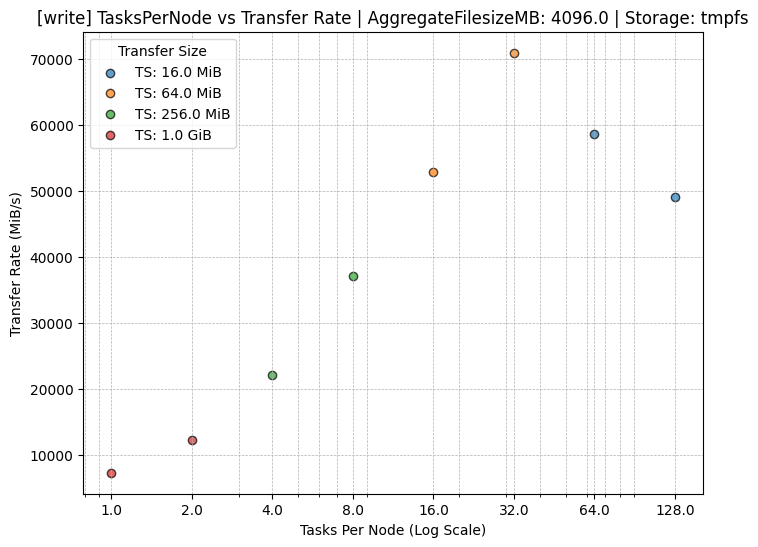

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

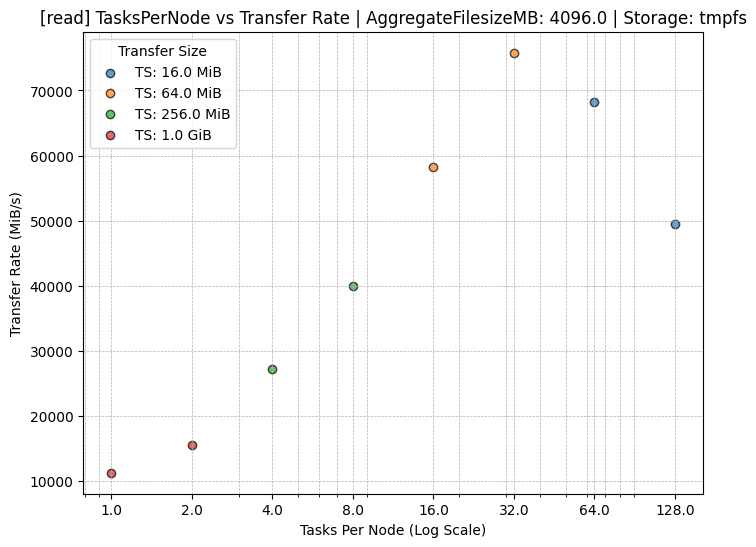

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 49152.0, TransferSize 16777216.0, Operation write


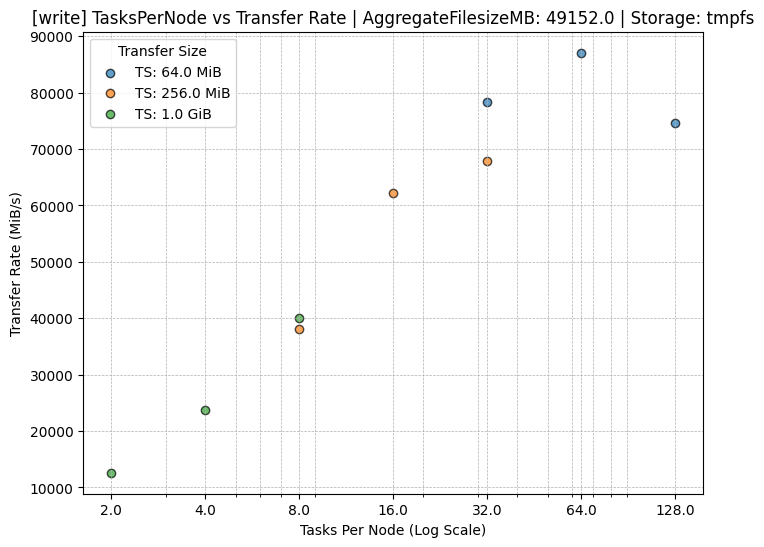

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecate

Skipping plot due to insufficient data points for AggregateFilesizeMB 49152.0, TransferSize 16777216.0, Operation read


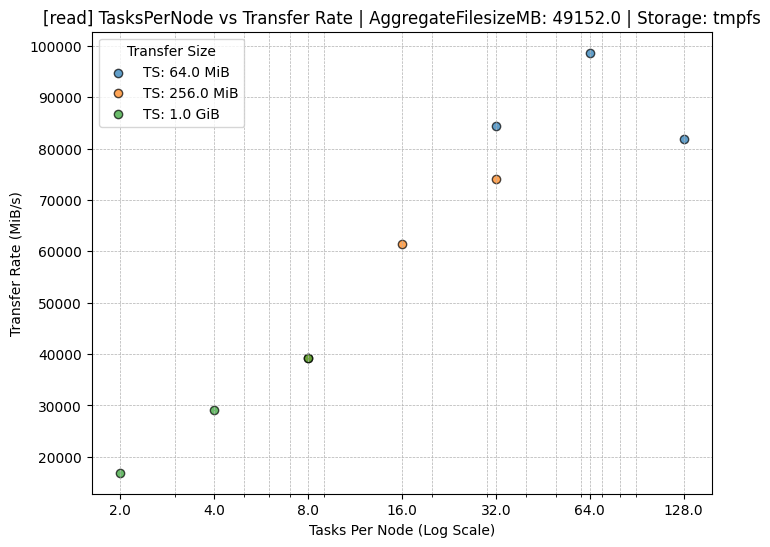

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with a

Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 268435456.0, Operation write
Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 1073741824.0, Operation write


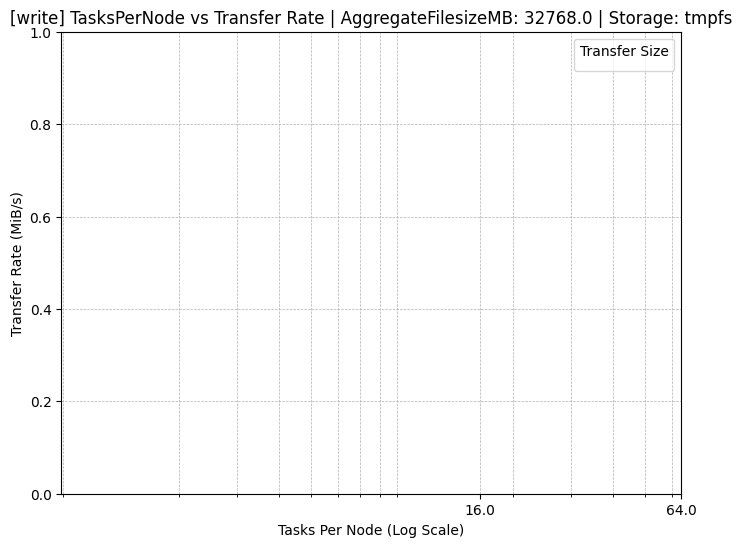

/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_tr_df = group.groupby('tasksPerNode').apply(
/tmp/ipykernel_159835/901205240.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with a

Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 268435456.0, Operation read
Skipping plot due to insufficient data points for AggregateFilesizeMB 32768.0, TransferSize 1073741824.0, Operation read


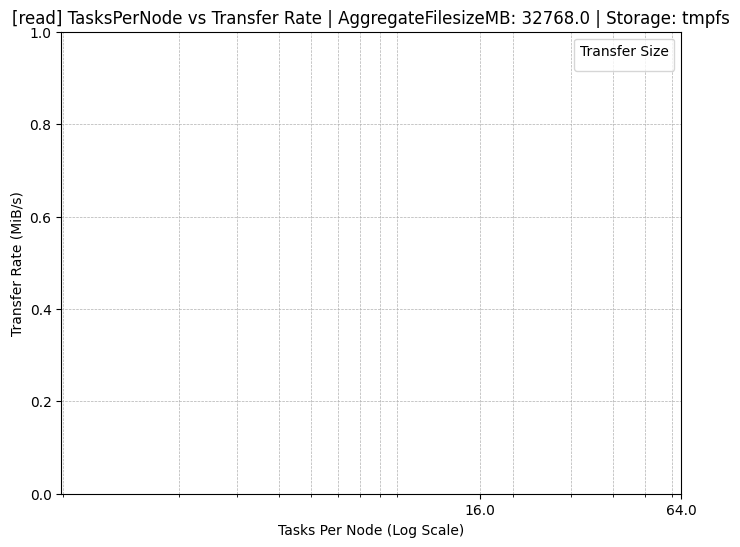

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_df_by_transfer_size(scaled_ior_df, numNodes=1):
    """
    Analyze the DataFrame by processing and plotting the transfer rate (trMiB) vs tasksPerNode
    for fixed values of aggregateFilesizeMB and operation types, using scatter points for unique transferSize.
    Now includes a log-scale x-axis with properly labeled ticks and grid lines.
    """
    storage_code = scaled_ior_df['storageType'].unique()[0]
    storage_type = decode_store_code(storage_code)

    # Get unique combinations of aggregateFilesizeMB and operation
    unique_combinations = scaled_ior_df[['aggregateFilesizeMB', 'operation']].drop_duplicates()

    for _, row in unique_combinations.iterrows():
        aggregate_size = row['aggregateFilesizeMB']
        operation = row['operation']
        op_dict = {0: "write", 1: "read"}

        # Filter by aggregateFilesizeMB and operation
        subdf = scaled_ior_df[
            (scaled_ior_df['aggregateFilesizeMB'] == aggregate_size) &
            (scaled_ior_df['operation'] == operation) &
            (scaled_ior_df['numNodes'] == numNodes)
        ]

        if not subdf.empty:
            # Group by transferSize
            grouped = subdf.groupby('transferSize')

            plt.figure(figsize=(8, 6))

            for transfer_size, group in grouped:
                ave_tr_df = group.groupby('tasksPerNode').apply(
                    lambda g: x_mean_std(g, 'trMiB')
                ).reset_index()

                if ave_tr_df.empty or len(ave_tr_df) < 2:
                    print(f"Skipping plot due to insufficient data points for AggregateFilesizeMB {aggregate_size}, TransferSize {transfer_size}, Operation {op_dict[operation]}")
                    continue

                # Scatter plot
                plt.scatter(
                    ave_tr_df['tasksPerNode'], ave_tr_df['trMiB_ave'],
                    label=f"TS: {byte_size_to_human_size(transfer_size)}",
                    alpha=0.7, edgecolors='k'
                )

            # Apply Log Scale to x-axis
            plt.xscale('log')

            # Set custom tick positions
            unique_tasks_per_node = sorted(subdf['tasksPerNode'].unique())
            plt.xticks(unique_tasks_per_node, labels=[str(t) for t in unique_tasks_per_node])

            # Grid settings (ensure grid lines on major ticks)
            plt.grid(True, which="both", linestyle="--", linewidth=0.5)

            # Plot Settings
            plt.xlabel("Tasks Per Node (Log Scale)")
            plt.ylabel("Transfer Rate (MiB/s)")
            plt.title(f"[{op_dict[operation]}] TasksPerNode vs Transfer Rate | AggregateFilesizeMB: {aggregate_size} | Storage: {storage_type}")
            plt.legend(title="Transfer Size")
            
            # Save the plot
            save_path = "./ior_seq_graph_tasksPerNode_byTransferSize"
            if not os.path.exists(save_path):
                os.makedirs(save_path)

            plot_filename = f"{save_path}/scatter_TasksPerNode_AggSize_{aggregate_size}_{op_dict[operation]}.png"
            plt.savefig(plot_filename, dpi=300)
            plt.show()

# # Example Usage
analyze_df_by_transfer_size(beegfs_df, numNodes=2)
# analyze_df_by_transfer_size(nfs_df, numNodes=2)
analyze_df_by_transfer_size(ssd_df, numNodes=2)
analyze_df_by_transfer_size(tmpfs_df, numNodes=2)


Filtered Rows: 48


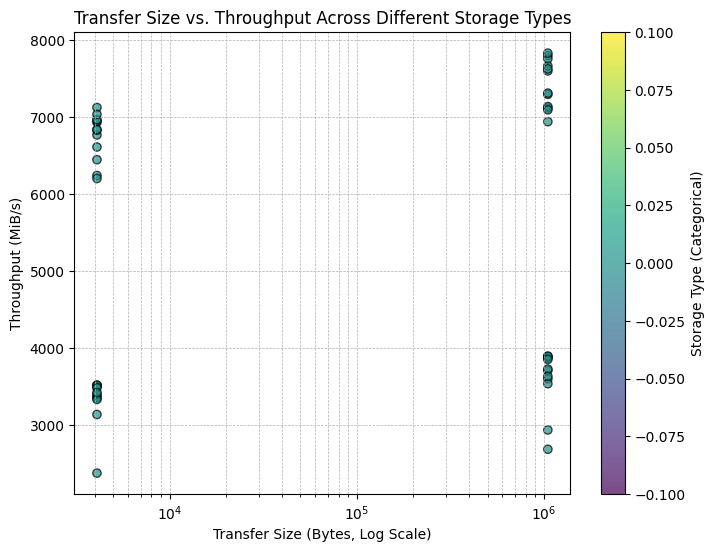

In [ ]:
# Plot Scatter Graph for Regression Diagram
filtered_df = ssd_df[
    (ssd_df['operation'] == 0) &
    (ssd_df['transferSize'].isin([4.09600000e+03, 1.04857600e+06])) &
    (ssd_df['numNodes'].isin([8, 16])) &
    (ssd_df['tasksPerNode'].isin([16, 32])) &
    (ssd_df['aggregateFilesizeMB'].isin([1024, 5120]))
]

print(f"Filtered Rows: {len(filtered_df)}")


# ---- Plot Example Graph ----
plt.figure(figsize=(8, 6))

# Scatter plot: Transfer Size vs. Throughput
scatter = plt.scatter(
    filtered_df['transferSize'], filtered_df['trMiB'],
    c=filtered_df['storageType'].astype('category').cat.codes, 
    cmap='viridis', alpha=0.7, edgecolors='k'
)

# Labels
plt.xscale('log')
plt.xlabel("Transfer Size (Bytes, Log Scale)")
plt.ylabel("Throughput (MiB/s)")
plt.title("Transfer Size vs. Throughput Across Different Storage Types")
plt.colorbar(label="Storage Type (Categorical)")

# Show plot
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

In [ ]:
# import pandas as pd

# def merge_multiple_by_test_param(df_list):
#     if len(df_list) != len(suffixes):
#         raise ValueError("The number of DataFrames must match the number of suffixes.")

#     merge_columns = ['randomOffset', 'transferSize', 'aggregateFilesizeMB',
#                      'numTasks', 'numNodes', 'parallelism', 'tasksPerNode']
    
#     # Start with the first dataframe
#     merged_df = df_list[0].copy()
#     current_suffix = suffixes[0]
    
#     for i in range(1, len(df_list)):
#         next_df = df_list[i]
#         next_suffix = suffixes[i]
#         merged_df = pd.merge(
#             merged_df,
#             next_df,
#             on=merge_columns,
#             suffixes=(f"_{current_suffix}", f"_{next_suffix}")
#         )
#         current_suffix += f"_{next_suffix}"  # track combined suffix

#     # Drop all `storageType_*` columns and unify `operation_*`
#     storage_cols = [col for col in merged_df.columns if col.startswith("storageType_")]
#     merged_df.drop(columns=storage_cols, inplace=True)

#     # Standardize `operation` column: keep the first occurrence
#     op_cols = [col for col in merged_df.columns if col.startswith("operation_")]
#     if op_cols:
#         merged_df.rename(columns={op_cols[0]: 'operation'}, inplace=True)
#         merged_df.drop(columns=op_cols[1:], inplace=True)

#     # Add a column indicating which storage has the smallest `trMiB` (lower is better)
#     tr_cols = [col for col in merged_df.columns if col.startswith("trMiB_")]
#     if len(tr_cols) >= 2:
#         merged_df['selectStorage'] = merged_df[tr_cols].idxmin(axis=1).apply(lambda x: x.split('_')[-1])

#     print(merged_df.head(5))
#     print(f"Merged shape: {merged_df.shape}")
#     for idx, df in enumerate(df_list):
#         print(f"df[{idx}] ({suffixes[idx]}).shape: {df.shape}")

#     return merged_df

# # df_list = [ssd_df, beegfs_df, nfs_df, tmpfs_df]
# # suffixes = ['ssd', 'beegfs', 'nfs', 'tmpfs']

# df_list = [ssd_df, beegfs_df]
# suffixes = ['ssd', 'beegfs']

# master_ior_df = merge_multiple_by_test_param(df_list, suffixes)
# # master_ior_df = merge_by_test_param(nfs_df, tmpfs_df)


# allColumns = master_ior_df.columns

# # master_ior_df = master_ior_df.group(allColumns).first()
# master_ior_df = master_ior_df.drop_duplicates(subset=allColumns)

# # Show 5 rows with selectStorage = 0
# print(f"Rows with selectStorage = {decode_store_code(0)}")
# print(master_ior_df[master_ior_df['selectStorage'] == 0].head(5))

# # Show 5 rows with selectStorage = 1
# print(f"Rows with selectStorage = {decode_store_code(1)}")
# print(master_ior_df[master_ior_df['selectStorage'] == 1].head(5))

# print("Shape of master_ior_df: ", master_ior_df.shape)

In [ ]:
def concat_and_pivot_by_test_param(df_list):
    # Concatenate all dataframes
    df_all = pd.concat(df_list, ignore_index=True)

    # Decode storageType
    df_all["storageStr"] = df_all["storageType"].apply(decode_store_code)

    # Drop storageType, we'll use storageStr in the pivot
    df_all = df_all.drop(columns=["storageType"])

    # Columns to use as identifiers (merge keys)
    merge_columns = ['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
                     'numTasks', 'numNodes', 'tasksPerNode', 'parallelism']

    # Pivot: trMiB and totalTime get suffixed by storageStr
    df_pivot = df_all.pivot_table(
        index=merge_columns,
        columns='storageStr',
        values=['trMiB', 'totalTime', 'trMiB_ave']
    ).reset_index()

    # Flatten column multi-index: ('trMiB', 'nfs') -> 'trMiB_nfs'
    df_pivot.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in df_pivot.columns]

    # Optional: select the fastest storage based on trMiB
    trmib_cols = [col for col in df_pivot.columns if col.startswith("trMiB_")]
    if trmib_cols:
        df_pivot['selectStorage'] = df_pivot[trmib_cols].idxmin(axis=1).str.replace("trMiB_", "", regex=False)
    
    print(f"Combined df size: {df_pivot.shape}")

    return df_pivot

df_list = [ssd_df, beegfs_df, tmpfs_df, nfs_df]

master_ior_df = concat_and_pivot_by_test_param(df_list)
# master_ior_df = merge_by_test_param(nfs_df, tmpfs_df)


allColumns = master_ior_df.columns

# master_ior_df = master_ior_df.group(allColumns).first()
master_ior_df = master_ior_df.drop_duplicates(subset=allColumns)

print("Shape of master_ior_df: ", master_ior_df.shape)

# Show the DataFrame with the new columns
print(master_ior_df.head(5))

# Save the merged DataFrame to a CSV file
master_ior_df.to_csv("master_ior_df.csv")

Combined df size: (1796, 21)
Shape of master_ior_df:  (1796, 21)
   operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
0        0.0           0.0          64.0               1024.0       2.0   
1        0.0           0.0          64.0               1024.0       2.0   
2        0.0           0.0          64.0               1024.0       4.0   
3        0.0           0.0          64.0               1024.0       4.0   
4        0.0           0.0          64.0               1024.0       4.0   

   numNodes  tasksPerNode  parallelism  totalTime_beegfs  totalTime_localssd  \
0       1.0           2.0          2.0          7.910233                 NaN   
1       2.0           1.0          2.0          4.367267            9.918333   
2       1.0           4.0          4.0          7.636533                 NaN   
3       2.0           2.0          4.0          2.209433           11.840200   
4       4.0           1.0          4.0          2.195800            4.937367   

   

In [ ]:
master_ior_df[master_ior_df['numNodes'] == 4]

,operation,randomOffset,transferSize,aggregateFilesizeMB,numTasks,numNodes,tasksPerNode,parallelism,totalTime_beegfs,totalTime_localssd,...,totalTime_tmpfs,trMiB_beegfs,trMiB_localssd,trMiB_nfs,trMiB_tmpfs,trMiB_ave_beegfs,trMiB_ave_localssd,trMiB_ave_nfs,trMiB_ave_tmpfs,selectStorage
4,0.0,0.0,6.400000e+01,1024.0,4.0,4.0,1.0,4.0,2.195800,4.937367,...,2.169233,466.350933,207.398733,196.888933,472.076900,354.638256,147.051433,139.833633,476.220567,ave_nfs
7,0.0,0.0,6.400000e+01,1024.0,8.0,4.0,2.0,8.0,1.115967,5.768233,...,1.076033,917.614967,177.580100,273.182967,951.702467,713.645108,218.361356,231.449758,952.019842,localssd
11,0.0,0.0,6.400000e+01,1024.0,16.0,4.0,4.0,16.0,0.593167,5.820533,...,0.538200,1730.130900,175.943567,338.487533,1902.638767,1379.428147,340.889017,289.946700,1641.722807,localssd
16,0.0,0.0,6.400000e+01,1024.0,32.0,4.0,8.0,32.0,0.348867,5.016033,...,0.271167,2983.135433,204.356067,385.106033,3776.319133,2254.738072,590.224000,501.942167,3329.676850,localssd
22,0.0,0.0,6.400000e+01,1024.0,64.0,4.0,16.0,64.0,0.264333,4.615200,...,0.135100,4177.985267,221.960000,413.719900,7578.633033,3571.930522,629.041073,531.365160,6012.623783,localssd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,1.0,0.0,1.073742e+09,49152.0,16.0,4.0,4.0,16.0,1.930533,1.020733,...,0.877967,25485.255867,49129.571333,NaN,55984.458300,20849.687092,66960.688453,NaN,45766.347667,ave_beegfs
1781,1.0,0.0,1.073742e+09,65536.0,64.0,4.0,16.0,64.0,NaN,1.124000,...,NaN,NaN,61502.041133,NaN,NaN,NaN,120554.450544,NaN,NaN,localssd
1784,1.0,0.0,1.073742e+09,98304.0,8.0,4.0,2.0,8.0,NaN,3.763667,...,NaN,NaN,26163.065167,NaN,NaN,NaN,30625.509317,NaN,NaN,localssd
1786,1.0,0.0,1.073742e+09,98304.0,16.0,4.0,4.0,16.0,NaN,1.946667,...,NaN,NaN,50505.738400,NaN,NaN,NaN,73638.407983,NaN,NaN,localssd


In [ ]:
ssd_df.columns, beegfs_df.columns

(Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
        'numTasks', 'totalTime', 'numNodes', 'tasksPerNode', 'parallelism',
        'trMiB', 'storageType', 'trMiB_ave', 'trMiB_ave_std',
        'trMiB_ave_std_perc', 'aggregateFilesizeMB_log', 'transferSize_log',
        'aggregateFilesizeMB_log_norm', 'trMiB_norm'],
       dtype='object'),
 Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
        'numTasks', 'totalTime', 'numNodes', 'tasksPerNode', 'parallelism',
        'trMiB', 'storageType', 'trMiB_ave', 'trMiB_ave_std',
        'trMiB_ave_std_perc', 'aggregateFilesizeMB_log', 'transferSize_log',
        'aggregateFilesizeMB_log_norm', 'trMiB_norm'],
       dtype='object'))

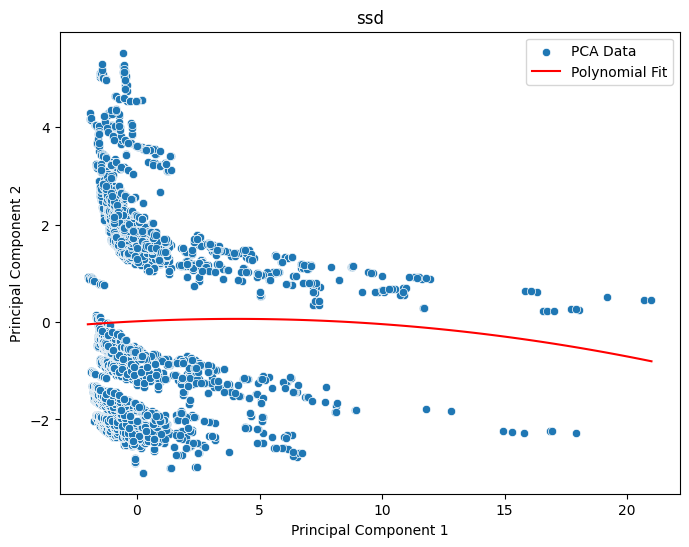

Polynomial fit parameters: a=-0.0030285203187667697, b=0.024484177045121736, c=0.014050678163954
Reconstruction error (MSE): 0.5004195635437947
Explained variance by principal components: [0.27290903 0.19723496]


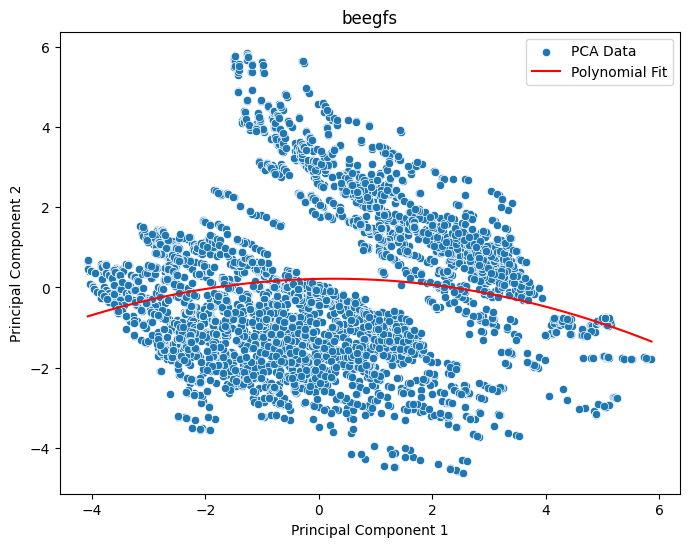

Polynomial fit parameters: a=-0.04998767634679835, b=0.026391353020814967, c=0.21230532943646796
Reconstruction error (MSE): 0.47004716695346765
Explained variance by principal components: [0.26544709 0.20574985]


In [ ]:

def _polynomial_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Define a polynomial function to fit
    def polynomial_func(x, a, b, c):
        return a * x**2 + b * x + c

    # Fit the polynomial curve
    params, _ = curve_fit(polynomial_func, pca_df['PC1'], pca_df['PC2'])

    # Predict values using the fitted curve
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_curve = polynomial_func(x_vals, *params)

    # Visualizing the PCA result and the fitted curve
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_curve, color='red', label='Polynomial Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Curve fit parameters
    print(f'Polynomial fit parameters: a={params[0]}, b={params[1]}, c={params[2]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')
    

_polynomial_fit_pca(ssd_df, title="ssd")
_polynomial_fit_pca(beegfs_df, title="beegfs")
# _linear_fit_pca(ssd_df, title="ssd")
# _linear_fit_pca(beegfs_df, title="beegfs")



In [ ]:
# # Show rows with RWR_ssd is nan
# print("Rows with nan RWR_ssd:")
# nan_rwr_df = master_ior_df[master_ior_df['RWR_ssd'].isna()]
# print(nan_rwr_df.shape)
# # Show the unique operations in the DataFrame
# print("Unique operations:")
# print(master_ior_df['operation'].unique())

# # Show the number range of RWR_beegfs
# print("RWR_beegfs range:")
# print(master_ior_df['RWR_beegfs'].describe())
# print()

# # Show the number range of RWR_ssd
# print("RWR_ssd range:")
# print(master_ior_df['RWR_ssd'].describe())
# # Show the rows with RWR_ssd.max
# max_rwr_ssd = master_ior_df[master_ior_df['RWR_ssd'] == master_ior_df['RWR_ssd'].max()]
# print("Rows with RWR_ssd.max:")
# print(max_rwr_ssd)
